In [1]:
# === Display multiple outputs in the same cell ===
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# === Core Python Packages ===
import os
import datetime
import warnings
warnings.filterwarnings('ignore')

# === Data Manipulation ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

# === Statistical Analysis ===
from scipy.stats import chi2_contingency, f_oneway, pearsonr

# === Scikit-learn: Preprocessing ===
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, label_binarize

# === Scikit-learn: Model Selection ===
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, 
    cross_val_score, learning_curve
)

# === Scikit-learn: Models ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# === Scikit-learn: Evaluation Metrics ===
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
    roc_curve, auc, make_scorer, precision_recall_curve
)

# === Imbalanced Data Handling ===
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

# === Utilities ===
import joblib
import shap


#### Project Introduction

Credit risk assessment is a fundamental task for financial institutions. Traditionally, it relies on expert judgment or scorecard systems to evaluate a client's ability to repay. This project leverages machine learning to **automatically classify credit applicants into three distinct risk categories:**

- **Good Client**
- **Low Risk**
- **High Risk**

The model is trained on historical financial and behavioral data to predict the client's risk profile.


**Important:** This is not a binary loan approval model (e.g., Approved/Rejected).

Instead, it aims to provide **a more nuanced, multi-class risk segmentation**, enabling better risk-based decision-making rather than simple application acceptance or denial.

This three-level classification can support more informed and personalized credit/loan strategies by:

This classification can help financial institutions make more informed decisions in areas such as:

- Setting appropriate credit limits
- Adjusting interest rates based on risk
- Enabling early identification of high-risk profiles

By focusing on **risk segmentation**, the model provides financial institutions with a **deeper understanding of client risk**, leading to smarter and **more ethical lending policies.**

By focusing on risk segmentation rather than binary approval, the model provides a more nuanced view of customer risk, enabling smarter and fairer credit policy strategies.

A core focus of the project is to ensure the model remains **fair, transparent, and free of unjust bias**. To achieve this, the model will be:

- Evaluated for fairness across sensitive attributes
- Interpretable using **explainable AI (XAI)** techniques such as SHAP
- Designed to comply with ethical standards in AI-driven credit systems


By automating the credit risk classification process with AI, the project seeks/goal to:
- Improve accuracy in credit risk classification
- Enhance transparency and interpretability of AI models
- Promote fair, responsible, and data-driven lending decisions


In [2]:
app_df = pd.read_csv('application_record.csv')
display(app_df.head())
print(f"Shape of df_application: {app_df.shape}")


credit_df = pd.read_csv('credit_record.csv')
display(credit_df.head())
print(f"Shape of df_credit: {credit_df.shape}")

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Shape of df_application: (438557, 18)


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


Shape of df_credit: (1048575, 3)


In [3]:
# Merge datasets on 'ID'
df_merged = pd.merge(app_df, credit_df, on='ID', how='inner')

# Define function to categorize credit risk based on STATUS codes
def categorize_risk(status_values):
    unique_statuses = set(status_values)
    if unique_statuses.issubset({'C', 'X', '0'}):
        return 0  # Good client
    elif any(s in ['3', '4', '5'] for s in status_values):
        return 2  # High risk
    elif any(s in ['1', '2'] for s in status_values):
        return 1  # Low risk
    else:
        return np.nan

# Apply risk classification per client
risk_per_client = credit_df.groupby('ID')['STATUS'].apply(categorize_risk).reset_index()
risk_per_client.columns = ['ID', 'Risk_Level']

# Compute Account Age as the max number of months tracked for each client
account_age = credit_df.groupby('ID')['MONTHS_BALANCE'].min().reset_index()
account_age['Account_Age'] = -account_age['MONTHS_BALANCE']  # make positive
account_age.drop(columns=['MONTHS_BALANCE'], inplace=True)

# Merge Risk_Level and Account_Age back into main application data
app_df = app_df.merge(risk_per_client, on='ID', how='inner')
app_df = app_df.merge(account_age, on='ID', how='inner')

# Final check
print("Risk level distribution:")
print(app_df['Risk_Level'].value_counts())

print("\nAccount Age stats:")
print(app_df['Account_Age'].describe())

display(app_df[['ID', 'Risk_Level', 'Account_Age']].head())
display(app_df.head())


Risk level distribution:
Risk_Level
0    32166
1     3989
2      302
Name: count, dtype: int64

Account Age stats:
count    36457.000000
mean        26.164193
std         16.501854
min          0.000000
25%         12.000000
50%         24.000000
75%         39.000000
max         60.000000
Name: Account_Age, dtype: float64


,ID,Risk_Level,Account_Age
0,5008804,1,15
1,5008805,1,14
2,5008806,0,29
3,5008808,0,4
4,5008809,0,26


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Risk_Level,Account_Age
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1,15
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1,14
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0,29
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0,4
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0,26


In [4]:
# Drop duplicated columns from intermediate merges
cols_to_drop = ['Risk_Level_x', 'Account_Age_x', 'Risk_Level_y', 'Account_Age_y']
app_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Check final structure
print("Final shape:", app_df.shape)
print("Columns:", app_df.columns.tolist())

Final shape: (36457, 20)
Columns: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'Risk_Level', 'Account_Age']


In [5]:
app_df.rename(columns={
    'ID': 'ID',
    'CODE_GENDER': 'Gender',
    'FLAG_OWN_CAR': 'Owns_Car',
    'FLAG_OWN_REALTY': 'Owns_Property',
    'CNT_CHILDREN': 'Children_Count',
    'AMT_INCOME_TOTAL': 'Income',
    'NAME_INCOME_TYPE': 'Income_Type',
    'NAME_EDUCATION_TYPE': 'Education_Level',
    'NAME_FAMILY_STATUS': 'Marital_Status',
    'NAME_HOUSING_TYPE': 'Housing_Type',
    'DAYS_BIRTH': 'Age',
    'DAYS_EMPLOYED': 'Employment_Duration',
    'FLAG_MOBIL': 'Has_Mobile',
    'FLAG_WORK_PHONE': 'Has_Work_Phone',
    'FLAG_PHONE': 'Has_Phone',
    'FLAG_EMAIL': 'Has_Email',
    'OCCUPATION_TYPE': 'Occupation',
    'CNT_FAM_MEMBERS': 'Family_Size',
    'Risk_Level': 'Risk_Level',
    'Account_Age': 'Account_Age'
}, inplace=True)

app_df.head()


,ID,Gender,Owns_Car,Owns_Property,Children_Count,Income,Income_Type,Education_Level,Marital_Status,Housing_Type,Age,Employment_Duration,Has_Mobile,Has_Work_Phone,Has_Phone,Has_Email,Occupation,Family_Size,Risk_Level,Account_Age
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1,15
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1,14
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0,29
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0,4
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0,26


In [6]:

# Replace special code 365243 with NaN
app_df['Employment_Duration'] = app_df['Employment_Duration'].replace(365243, np.nan)

# Convert negative values to positive years
app_df['Employment_Duration'] = (-app_df['Employment_Duration'] / 365.25).round(1)

# Convert negative days of birth to positive age in years
app_df['Age'] = (-app_df['Age'] / 365.25).round(1)

# Flag for unemployed (1 if Employment_Duration is NaN, 0 otherwise)
app_df['Is_Unemployed'] = app_df['Employment_Duration'].isna().astype('Int64')

# Distribuția Risk_Level în funcție de Is_Unemployed
distribution = app_df.groupby('Is_Unemployed')['Risk_Level'].value_counts(normalize=True).unstack().round(4) * 100

print("Risk Level Distribution by Employment Status (%):")
print(distribution)

# Confirm changes
print(app_df['Is_Unemployed'].value_counts()) # 0 (Employed ) and 1 (Unemployed or Inactive)
print("\nData cleaned.")
print(app_df.info())
display(app_df.head())

Risk Level Distribution by Employment Status (%):
Risk_Level         0      1     2
Is_Unemployed                    
0              87.92  11.30  0.78
1              89.78   9.18  1.04
Is_Unemployed
0    30322
1     6135
Name: count, dtype: Int64

Data cleaned.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   Gender               36457 non-null  object 
 2   Owns_Car             36457 non-null  object 
 3   Owns_Property        36457 non-null  object 
 4   Children_Count       36457 non-null  int64  
 5   Income               36457 non-null  float64
 6   Income_Type          36457 non-null  object 
 7   Education_Level      36457 non-null  object 
 8   Marital_Status       36457 non-null  object 
 9   Housing_Type         36457 non-null  object 
 10  Age                  36

,ID,Gender,Owns_Car,Owns_Property,Children_Count,Income,Income_Type,Education_Level,Marital_Status,Housing_Type,...,Employment_Duration,Has_Mobile,Has_Work_Phone,Has_Phone,Has_Email,Occupation,Family_Size,Risk_Level,Account_Age,Is_Unemployed
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12.4,1,1,0,0,NaN,2.0,1,15,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,12.4,1,1,0,0,NaN,2.0,1,14,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,3.1,1,0,0,0,Security staff,2.0,0,29,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,8.4,1,0,1,1,Sales staff,1.0,0,4,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,8.4,1,0,1,1,Sales staff,1.0,0,26,0


## Data Types and Missing Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   Gender               36457 non-null  object 
 2   Owns_Car             36457 non-null  object 
 3   Owns_Property        36457 non-null  object 
 4   Children_Count       36457 non-null  int64  
 5   Income               36457 non-null  float64
 6   Income_Type          36457 non-null  object 
 7   Education_Level      36457 non-null  object 
 8   Marital_Status       36457 non-null  object 
 9   Housing_Type         36457 non-null  object 
 10  Age                  36457 non-null  float64
 11  Employment_Duration  30322 non-null  float64
 12  Has_Mobile           36457 non-null  int64  
 13  Has_Work_Phone       36457 non-null  int64  
 14  Has_Phone            36457 non-null  int64  
 15  Ha

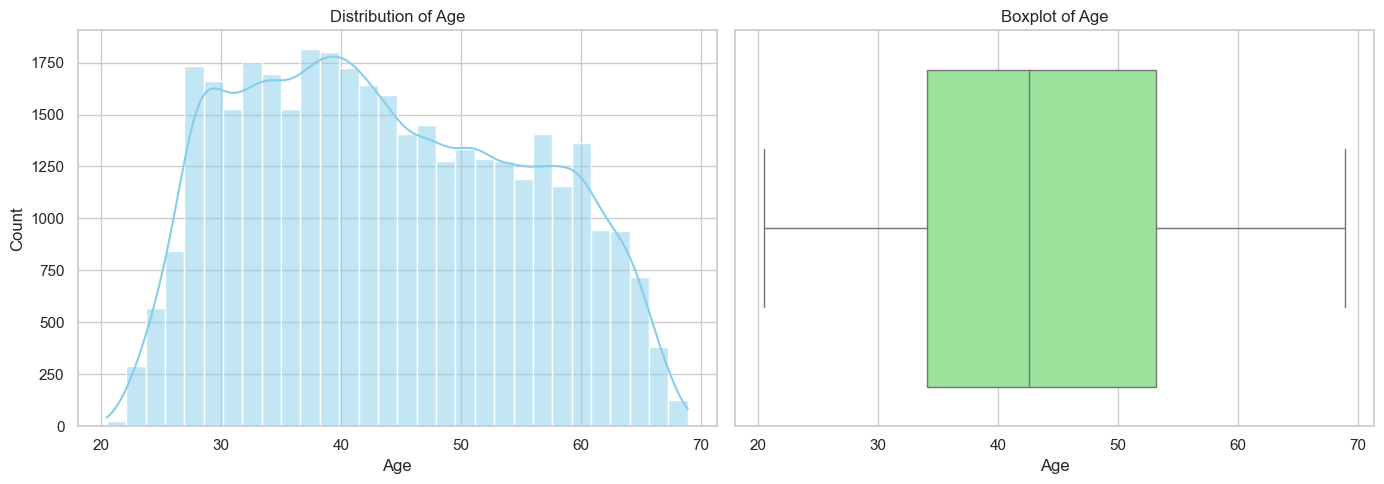


Age Summary Statistics:
count    36457.000000
mean        43.738802
std         11.499888
min         20.500000
25%         34.100000
50%         42.600000
75%         53.200000
max         68.900000
Name: Age, dtype: float64


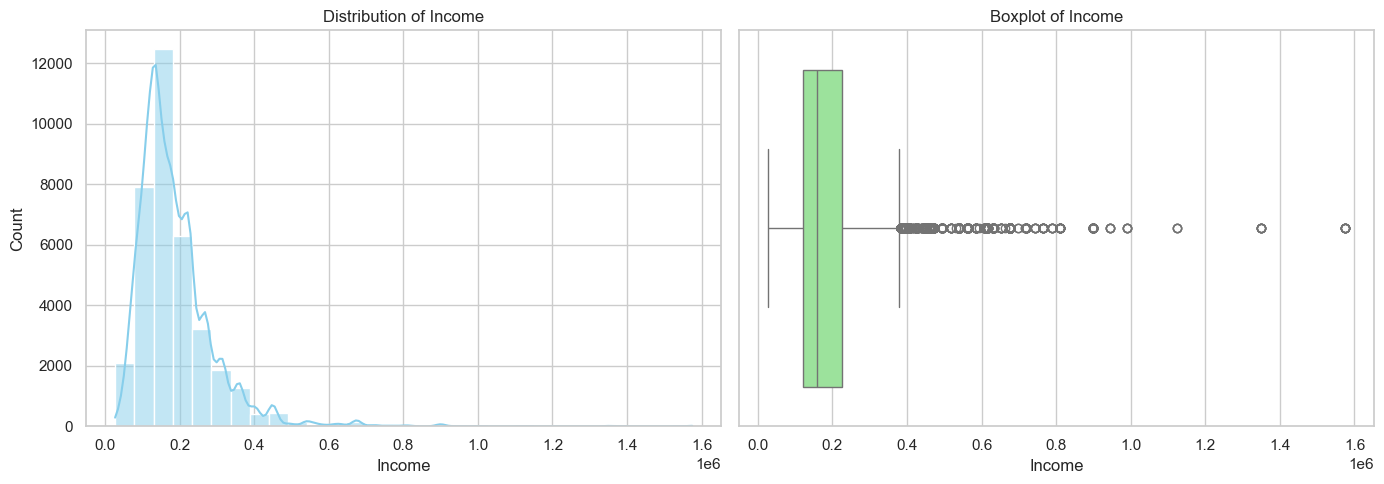


Income Summary Statistics:
count    3.645700e+04
mean     1.866857e+05
std      1.017892e+05
min      2.700000e+04
25%      1.215000e+05
50%      1.575000e+05
75%      2.250000e+05
max      1.575000e+06
Name: Income, dtype: float64


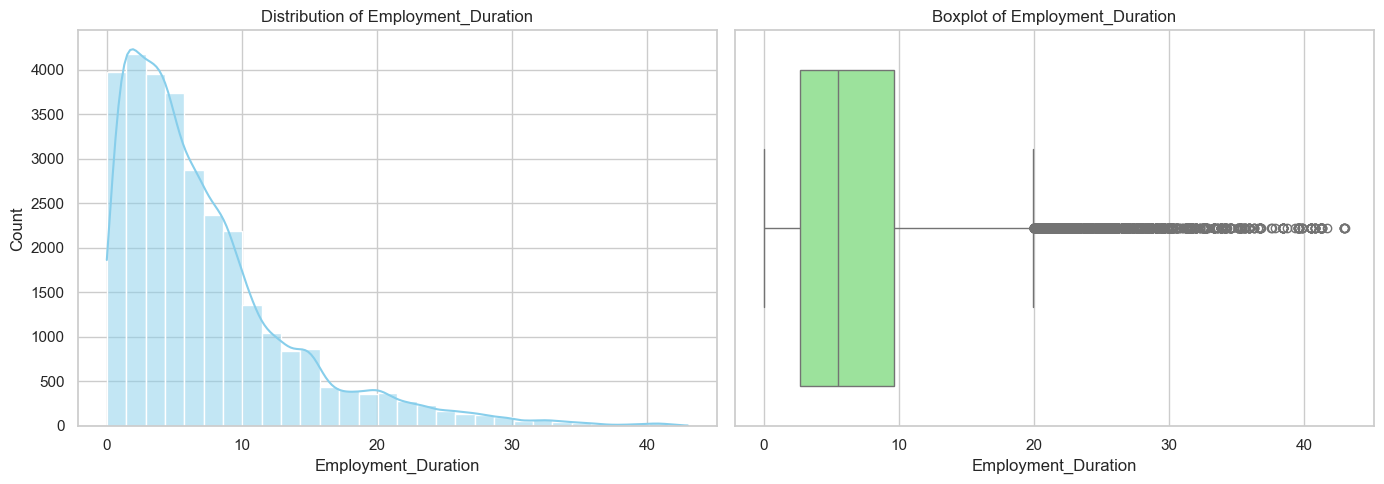


Employment_Duration Summary Statistics:
count    30322.000000
mean         7.242504
std          6.454489
min          0.000000
25%          2.700000
50%          5.500000
75%          9.600000
max         43.000000
Name: Employment_Duration, dtype: float64


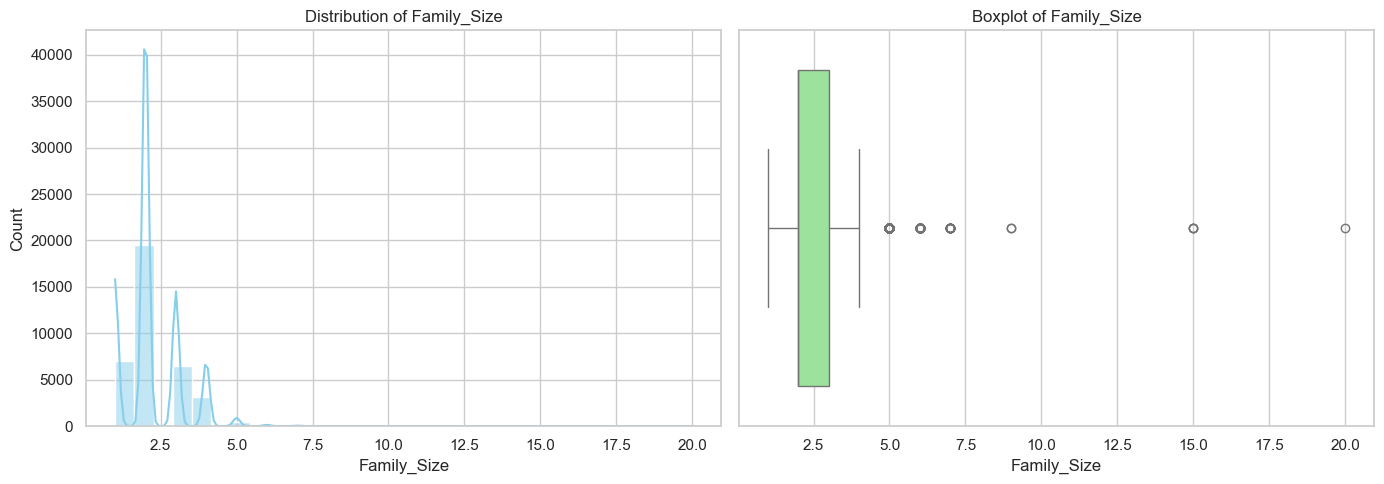


Family_Size Summary Statistics:
count    36457.000000
mean         2.198453
std          0.911686
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         20.000000
Name: Family_Size, dtype: float64


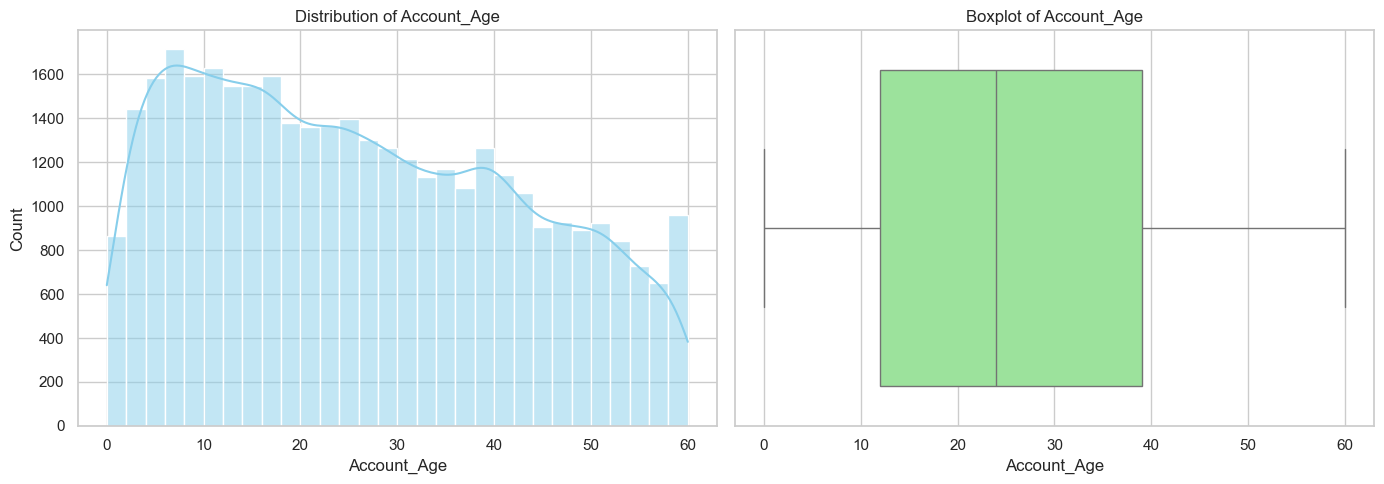


Account_Age Summary Statistics:
count    36457.000000
mean        26.164193
std         16.501854
min          0.000000
25%         12.000000
50%         24.000000
75%         39.000000
max         60.000000
Name: Account_Age, dtype: float64


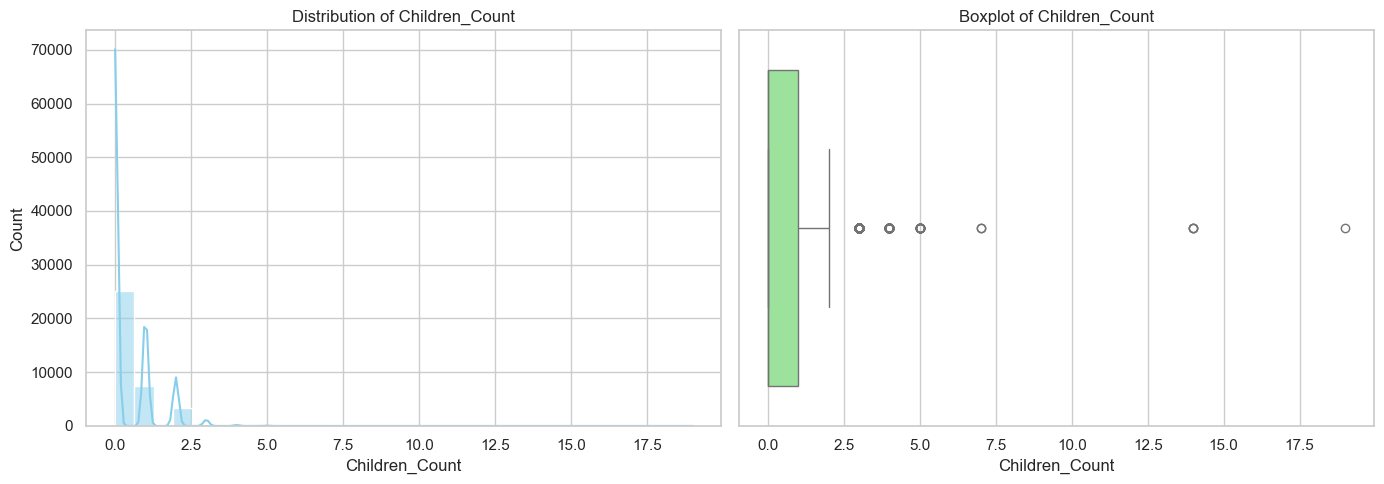


Children_Count Summary Statistics:
count    36457.000000
mean         0.430315
std          0.742367
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         19.000000
Name: Children_Count, dtype: float64


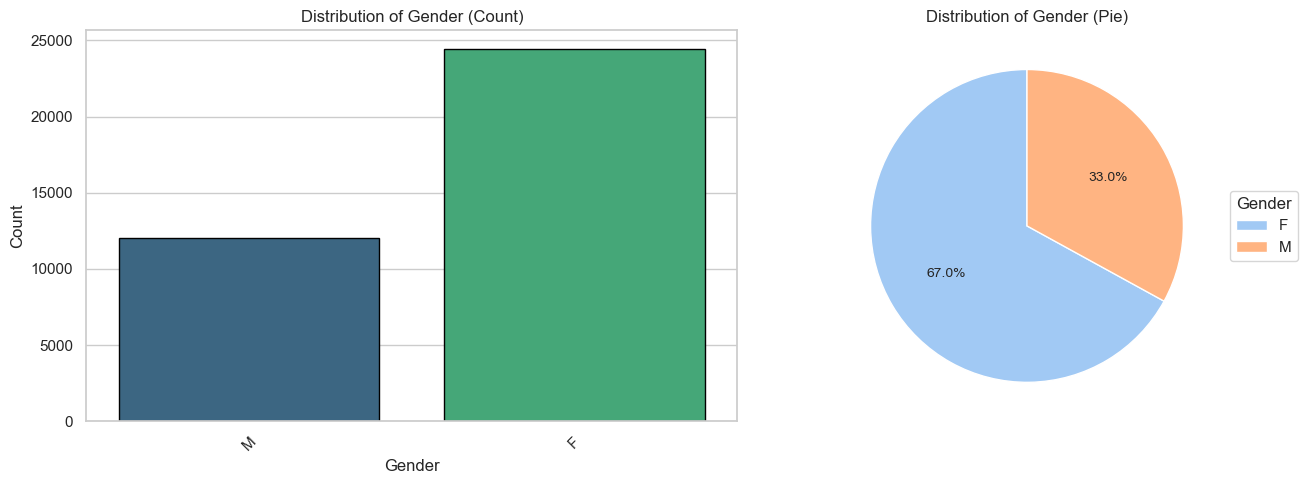


Gender Value Counts (%):
Gender
F    67.01
M    32.99
Name: count, dtype: float64


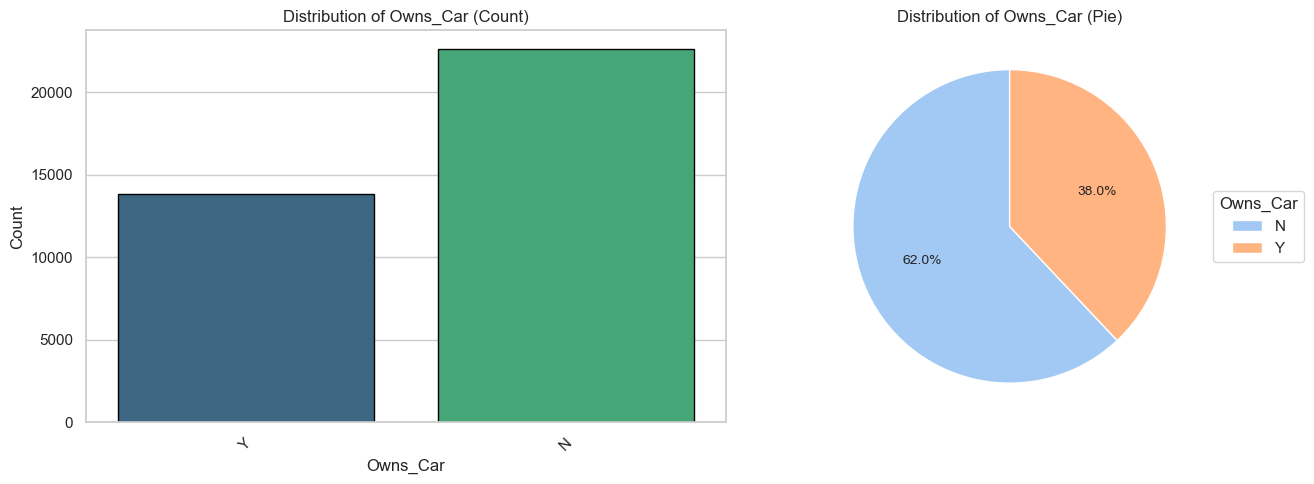


Owns_Car Value Counts (%):
Owns_Car
N    62.03
Y    37.97
Name: count, dtype: float64


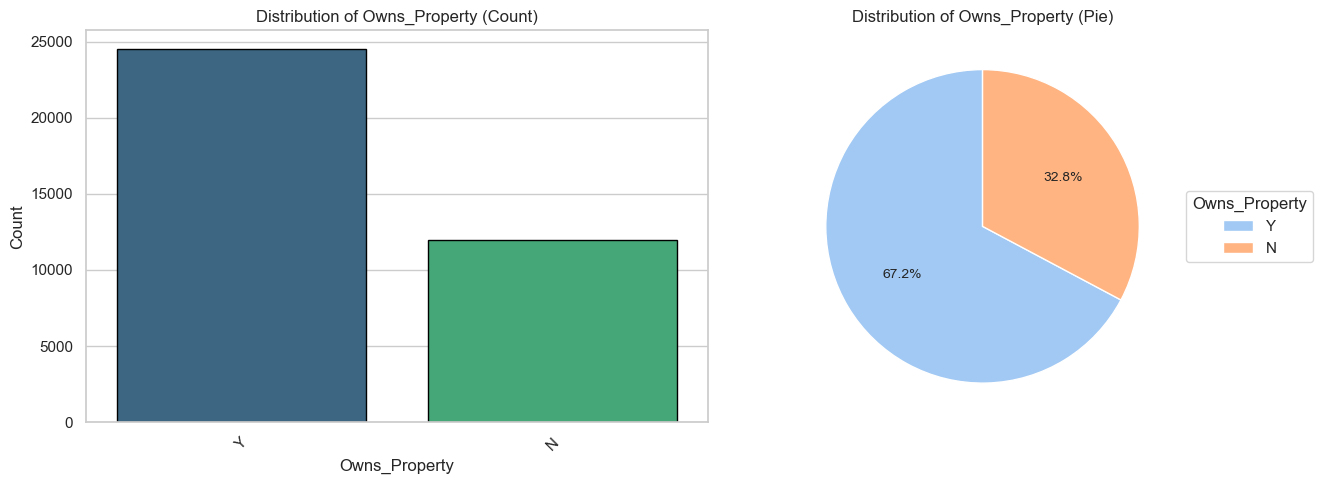


Owns_Property Value Counts (%):
Owns_Property
Y    67.22
N    32.78
Name: count, dtype: float64


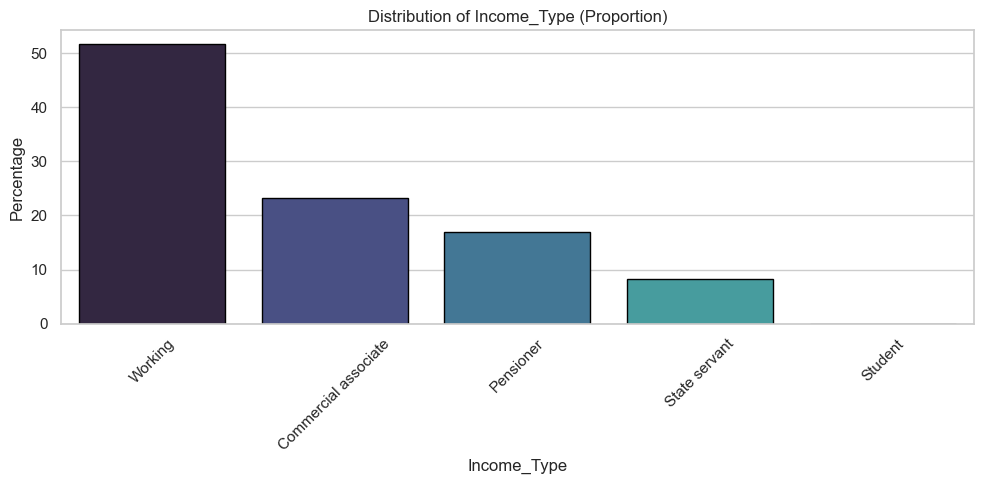


Income_Type Value Counts (%):
Income_Type
Working                 51.62
Commercial associate    23.29
Pensioner               16.87
State servant            8.19
Student                  0.03
Name: proportion, dtype: float64


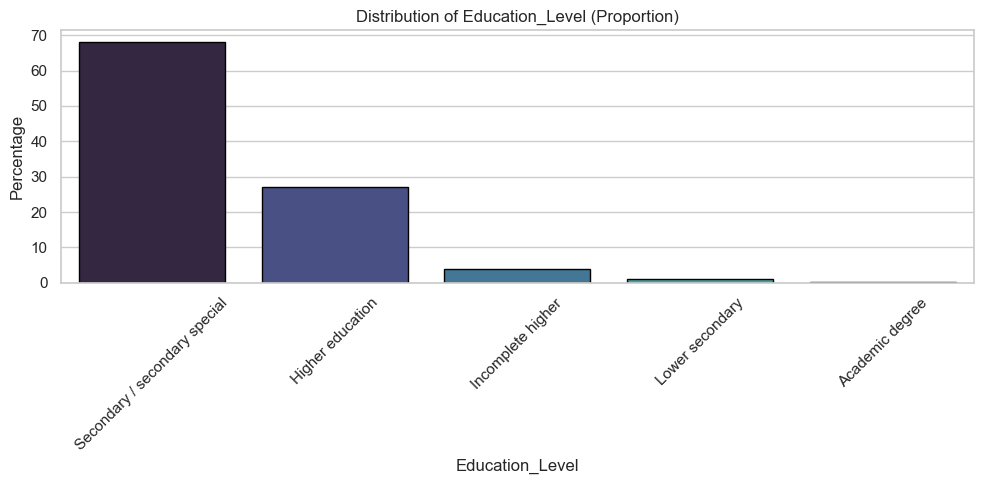


Education_Level Value Counts (%):
Education_Level
Secondary / secondary special    67.96
Higher education                 27.06
Incomplete higher                 3.87
Lower secondary                   1.03
Academic degree                   0.09
Name: proportion, dtype: float64


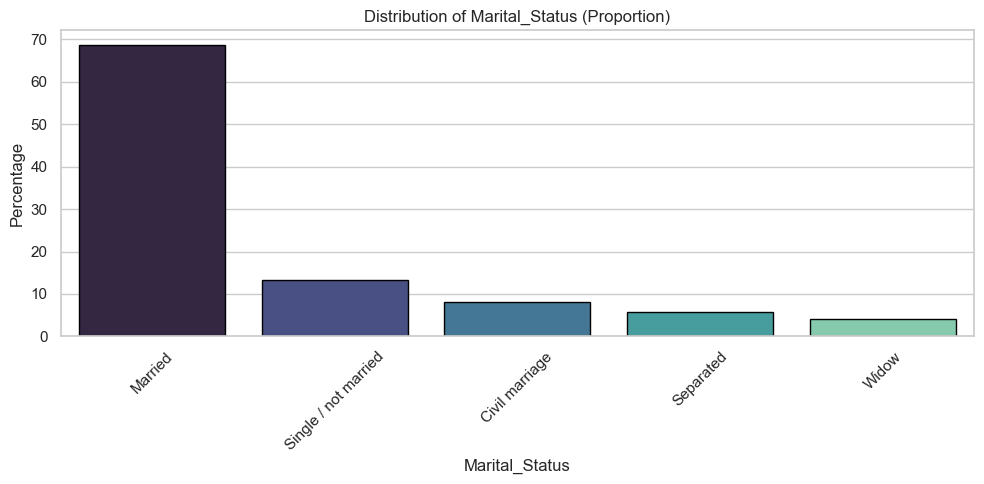


Marital_Status Value Counts (%):
Marital_Status
Married                 68.71
Single / not married    13.25
Civil marriage           8.08
Separated                5.77
Widow                    4.20
Name: proportion, dtype: float64


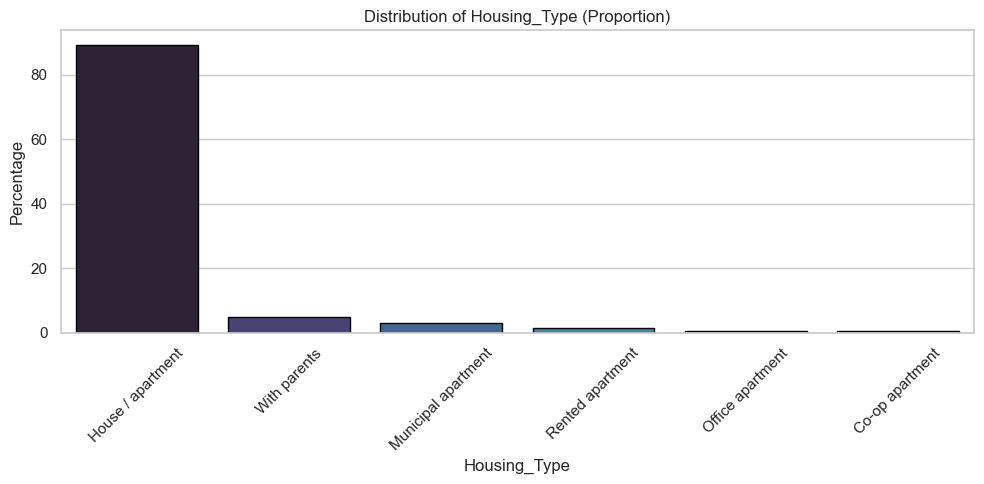


Housing_Type Value Counts (%):
Housing_Type
House / apartment      89.28
With parents            4.87
Municipal apartment     3.09
Rented apartment        1.58
Office apartment        0.72
Co-op apartment         0.46
Name: proportion, dtype: float64


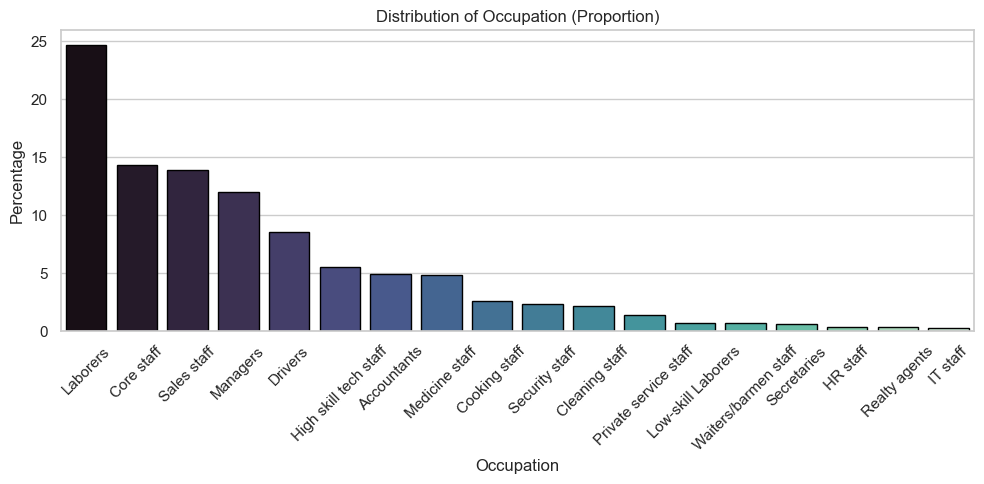


Occupation Value Counts (%):
Occupation
Laborers                 24.71
Core staff               14.29
Sales staff              13.87
Managers                 11.98
Drivers                   8.51
High skill tech staff     5.50
Accountants               4.94
Medicine staff            4.80
Cooking staff             2.61
Security staff            2.36
Cleaning staff            2.19
Private service staff     1.37
Low-skill Laborers        0.70
Waiters/barmen staff      0.69
Secretaries               0.60
HR staff                  0.34
Realty agents             0.31
IT staff                  0.24
Name: proportion, dtype: float64


<Figure size 600x400 with 0 Axes>

<Axes: xlabel='Risk_Level', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Credit Risk Levels')

Text(0.5, 0, 'Risk_Level (Target)')

Text(0, 0.5, 'Frequency')

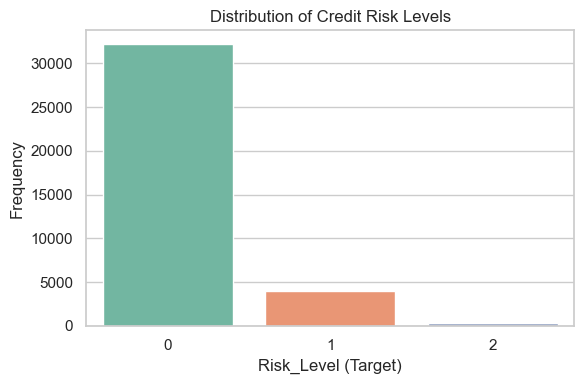


Risk_Level Value Counts (%):
Risk_Level
0    88.23
1    10.94
2     0.83
Name: proportion, dtype: float64


In [7]:

sns.set(style="whitegrid")

# =========================
# 1. Data Overview
# =========================
print("## Data Types and Missing Values\n")
print(app_df.info())

print("\n## Missing Values (%):")
missing_values = (app_df.isnull().sum() / len(app_df)) * 100
print(missing_values.round(2))


# =========================
# 2. Numerical Features
# =========================
def plot_numerical_distribution(df, column):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column], kde=True, ax=axs[0], bins=30, color='skyblue')
    axs[0].set_title(f'Distribution of {column}')
    axs[0].set_xlabel(column)
    axs[0].set_ylabel('Count')

    sns.boxplot(x=df[column], ax=axs[1], color='lightgreen')
    axs[1].set_title(f'Boxplot of {column}')
    axs[1].set_xlabel(column)

    plt.tight_layout()
    plt.show()

    # Show summary statistics below the plots
    print(f"\n{column} Summary Statistics:")
    print(df[column].describe())

# Add all relevant numerical columns here
numerical_cols = ['Age', 'Income', 'Employment_Duration', 'Family_Size', 'Account_Age', 'Children_Count']
for col in numerical_cols:
    plot_numerical_distribution(app_df, col)

# =========================
# 3. Categorical Features
# =========================

# Short categories (few unique values) -> Pie Chart + Countplot
short_cats = ['Gender', 'Owns_Car', 'Owns_Property']
# Long categories (many unique values) -> Barplot (%)
long_cats = ['Income_Type', 'Education_Level', 'Marital_Status', 'Housing_Type', 'Occupation']

def plot_short_categorical(df, column):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(x=column, data=df, ax=axs[0], palette='viridis', edgecolor='black')
    axs[0].set_title(f'Distribution of {column} (Count)')
    axs[0].set_ylabel('Count')
    axs[0].tick_params(axis='x', rotation=45)

    counts = df[column].value_counts()
    wedges, _, autotexts = axs[1].pie(
        counts, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('pastel'), textprops={'fontsize': 10}
    )
    axs[1].legend(wedges, counts.index, title=column, loc='center left', bbox_to_anchor=(1, 0.5))
    axs[1].set_title(f'Distribution of {column} (Pie)')

    plt.tight_layout()
    plt.show()

    print(f"\n{column} Value Counts (%):")
    print((counts / len(df) * 100).round(2))

def plot_long_categorical(df, column):
    plt.figure(figsize=(10, 5))
    percentages = (df[column].value_counts(normalize=True) * 100).sort_values(ascending=False)
    sns.barplot(x=percentages.index, y=percentages.values, palette='mako', edgecolor='black')
    plt.title(f'Distribution of {column} (Proportion)')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"\n{column} Value Counts (%):")
    print(percentages.round(2))

# Plot for both types of categorical features
for col in short_cats:
    plot_short_categorical(app_df, col)

for col in long_cats:
    plot_long_categorical(app_df, col)

# =========================
# 4. Target Variable: Risk_Level
# =========================
plt.figure(figsize=(6, 4))
sns.countplot(x='Risk_Level', data=app_df, palette='Set2')
plt.title('Distribution of Credit Risk Levels')
plt.xlabel('Risk_Level (Target)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\nRisk_Level Value Counts (%):")
print(app_df['Risk_Level'].value_counts(normalize=True).mul(100).round(2))



In [8]:

# Impute missing Occupation with 'Unknown'
app_df['Occupation'] = app_df['Occupation'].fillna('Unknown')

# 3. Drop irrelevant binary flags
irrelevant_cols = ['Has_Mobile', 'Has_Work_Phone', 'Has_Phone', 'Has_Email']
app_df.drop(columns=irrelevant_cols, inplace=True)

# Confirm changes
print("\nData cleaned.")
print(app_df.info())
display(app_df.head())



Data cleaned.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   Gender               36457 non-null  object 
 2   Owns_Car             36457 non-null  object 
 3   Owns_Property        36457 non-null  object 
 4   Children_Count       36457 non-null  int64  
 5   Income               36457 non-null  float64
 6   Income_Type          36457 non-null  object 
 7   Education_Level      36457 non-null  object 
 8   Marital_Status       36457 non-null  object 
 9   Housing_Type         36457 non-null  object 
 10  Age                  36457 non-null  float64
 11  Employment_Duration  30322 non-null  float64
 12  Occupation           36457 non-null  object 
 13  Family_Size          36457 non-null  float64
 14  Risk_Level           36457 non-null  int64  
 15  Account_Age          

,ID,Gender,Owns_Car,Owns_Property,Children_Count,Income,Income_Type,Education_Level,Marital_Status,Housing_Type,Age,Employment_Duration,Occupation,Family_Size,Risk_Level,Account_Age,Is_Unemployed
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,32.9,12.4,Unknown,2.0,1,15,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,32.9,12.4,Unknown,2.0,1,14,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,58.8,3.1,Security staff,2.0,0,29,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.3,8.4,Sales staff,1.0,0,4,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.3,8.4,Sales staff,1.0,0,26,0


In [9]:
# List of numerical columns for outlier analysis
numerical_cols = ['Income', 'Family_Size', 'Age', 'Account_Age', 'Children_Count']

# Function to detect outliers using the IQR method
def detect_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Print outlier counts per column
for col in numerical_cols:
    outliers = detect_iqr_outliers(app_df, col)
    print(f"{col}: {len(outliers)} outliers")

# === Remove outliers ===
def remove_iqr_outliers(df, columns):
    df_cleaned = df.copy()
    for column in columns:
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]
    return df_cleaned

# Apply outlier removal and save the cleaned dataset
df_cleaned_iqr = remove_iqr_outliers(app_df, numerical_cols)

# Compare dataset shapes
print(f"\nOriginal shape: {df_merged.shape}")
print(f"After outlier removal: {df_cleaned_iqr.shape}")


Income: 1529 outliers
Family_Size: 480 outliers
Age: 0 outliers
Account_Age: 0 outliers
Children_Count: 508 outliers

Original shape: (777715, 20)
After outlier removal: (34455, 17)


In [10]:
# Save the cleaned DataFrame to CSV
df_cleaned_iqr.to_csv('df_clients_cleaned.csv', index=False)

print("Cleaned dataset saved as 'df_clients_cleaned.csv'")

Cleaned dataset saved as 'df_clients_cleaned.csv'


In [11]:

df = df_cleaned_iqr.copy()

# Ensure Is_Unemployed is treated as a categorical variable
# Map 0/1 to string labels for clarity 
df['Is_Unemployed'] = df['Is_Unemployed'].map({0: 'Employed', 1: 'Unemployed'}).astype('category')

# List of categorical features to test against Credit_Risk
categorical_features = ['Gender', 'Owns_Car', 'Owns_Property', 'Income_Type',
                        'Education_Level', 'Marital_Status', 'Housing_Type',
                        'Occupation', 'Is_Unemployed']

# Store results
chi2_results = []

# Perform Chi-Squared test for each categorical feature
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['Risk_Level'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    chi2_results.append({
        'Feature': feature,
        'Chi2 Statistic': round(chi2, 4),
        'Degrees of Freedom': dof,
        'p-value': round(p, 6),
        'Significant (p < 0.05)': 'Yes' if p < 0.05 else 'No'
    })

# Display results
chi2_df = pd.DataFrame(chi2_results)
print("Chi-Squared Test Results:")
display(chi2_df)

# Chow contingency tables for significant features
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['Risk_Level'])
    print(f"\nContingency Table: {feature} vs Risk_Level")
    print(contingency_table)



Chi-Squared Test Results:


,Feature,Chi2 Statistic,Degrees of Freedom,p-value,Significant (p < 0.05)
0,Gender,12.7080,2,0.001740,Yes
1,Owns_Car,4.6472,2,0.097918,No
2,Owns_Property,30.8978,2,0.000000,Yes
3,Income_Type,42.2321,8,0.000001,Yes
4,Education_Level,30.0764,8,0.000205,Yes
5,Marital_Status,35.9278,8,0.000018,Yes
6,Housing_Type,29.1540,10,0.001176,Yes
7,Occupation,99.6195,36,0.000000,Yes
8,Is_Unemployed,27.9321,2,0.000001,Yes



Contingency Table: Gender vs Risk_Level
Risk_Level      0     1    2
Gender                      
F           20745  2451  178
M            9689  1294   98

Contingency Table: Owns_Car vs Risk_Level
Risk_Level      0     1    2
Owns_Car                    
N           19167  2419  182
Y           11267  1326   94

Contingency Table: Owns_Property vs Risk_Level
Risk_Level         0     1    2
Owns_Property                  
N               9935  1374  111
Y              20499  2371  165

Contingency Table: Income_Type vs Risk_Level
Risk_Level                0     1    2
Income_Type                           
Commercial associate   6823   910   68
Pensioner              5420   560   69
State servant          2400   347   19
Student                  10     1    0
Working               15781  1927  120

Contingency Table: Education_Level vs Risk_Level
Risk_Level                         0     1    2
Education_Level                                
Academic degree                   24     7 

In [12]:

df = df_cleaned_iqr.copy()

# Ensure the Risk_Level order is 0, 1, 2 (Good, Low, High Risk)
risk_levels = sorted(df['Risk_Level'].unique())

# List of numerical features to test
numerical_features = ['Income', 'Family_Size', 'Age', 'Employment_Duration', 'Account_Age', 'Children_Count']

anova_results = []

for feature in numerical_features:
    # Gather data by risk level, drop NaN values
    groups = [df[df['Risk_Level'] == level][feature].dropna() for level in risk_levels]
    f_stat, p_val = f_oneway(*groups)

    # Group sizes (for reporting)
    group_sizes = [len(g) for g in groups]
    group_means = [round(g.mean(), 2) for g in groups]

    anova_results.append({
        'Feature': feature,
        'F-Statistic': round(f_stat, 4),
        'p-value': round(p_val, 6),
        'Significant (p < 0.05)': 'Yes' if p_val < 0.05 else 'No',
        'N0': group_sizes[0],  # Count Good
        'N1': group_sizes[1],  # Count Low
        'N2': group_sizes[2],  # Count High
        'Mean0': group_means[0],
        'Mean1': group_means[1],
        'Mean2': group_means[2],
    })

anova_df = pd.DataFrame(anova_results)
print("ANOVA Test Results:")
display(anova_df)



ANOVA Test Results:


,Feature,F-Statistic,p-value,Significant (p < 0.05),N0,N1,N2,Mean0,Mean1,Mean2
0,Income,3.0738,0.046259,Yes,30434,3745,276,172609.99,175641.49,171414.13
1,Family_Size,4.8887,0.007536,Yes,30434,3745,276,2.15,2.17,2.02
2,Age,20.4373,0.000000,Yes,30434,3745,276,43.95,42.76,45.54
3,Employment_Duration,3.5434,0.028929,Yes,25014,3193,212,7.25,7.17,6.08
4,Account_Age,102.5098,0.000000,Yes,30434,3745,276,25.76,28.68,36.03
5,Children_Count,3.0646,0.046684,Yes,30434,3745,276,0.39,0.40,0.32


<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix (Numerical Features + Risk Level)')

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'Income'),
  Text(1.5, 0, 'Family_Size'),
  Text(2.5, 0, 'Age'),
  Text(3.5, 0, 'Employment_Duration'),
  Text(4.5, 0, 'Account_Age'),
  Text(5.5, 0, 'Is_Unemployed'),
  Text(6.5, 0, 'Children_Count'),
  Text(7.5, 0, 'Risk_Level')])

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0, 0.5, 'Income'),
  Text(0, 1.5, 'Family_Size'),
  Text(0, 2.5, 'Age'),
  Text(0, 3.5, 'Employment_Duration'),
  Text(0, 4.5, 'Account_Age'),
  Text(0, 5.5, 'Is_Unemployed'),
  Text(0, 6.5, 'Children_Count'),
  Text(0, 7.5, 'Risk_Level')])

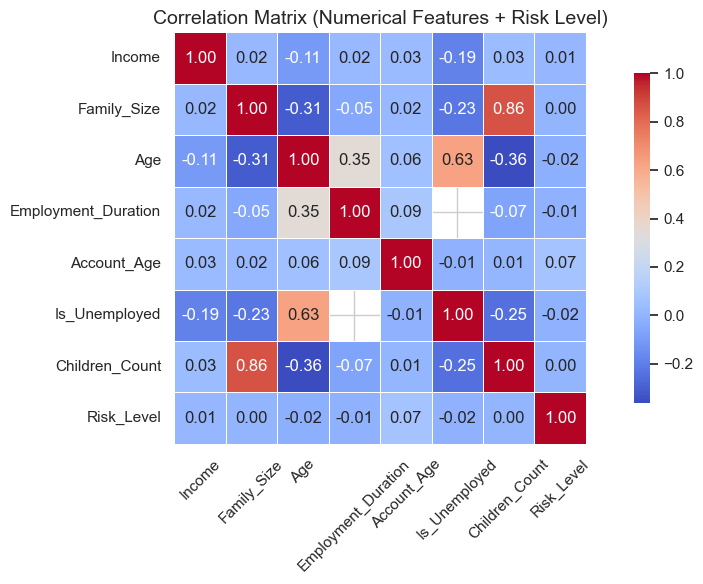


Correlation with Risk Level (sorted):
Account_Age            0.0740
Income                 0.0107
Children_Count         0.0031
Family_Size            0.0014
Employment_Duration   -0.0103
Is_Unemployed         -0.0157
Age                   -0.0217
Name: Risk_Level, dtype: float64


In [13]:

# Include target to evaluate how correlated each feature is with Risk_Level
numeric_cols_with_target = ['Income', 'Family_Size', 'Age', 'Employment_Duration',
                            'Account_Age', 'Is_Unemployed', 'Children_Count', 'Risk_Level']

# Compute correlation
corr_matrix = df[numeric_cols_with_target].corr()

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Numerical Features + Risk Level)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print sorted correlation with target
print("\nCorrelation with Risk Level (sorted):")
correlation_with_target = corr_matrix['Risk_Level'].drop('Risk_Level').sort_values(ascending=False)
print(correlation_with_target.round(4))


In [14]:
print(df_cleaned_iqr['Is_Unemployed'].value_counts(dropna=False))
print(df_cleaned_iqr['Is_Unemployed'].unique())


Is_Unemployed
0    28419
1     6036
Name: count, dtype: Int64
<IntegerArray>
[0, 1]
Length: 2, dtype: Int64


Correlation Matrix (Numerical Features only):


,Income,Family_Size,Age,Employment_Duration,Account_Age,Children_Count
Income,NaN,0.0186,-0.1054,0.0210,0.0264,0.0345
Family_Size,0.0186,NaN,-0.3111,-0.0502,0.0237,0.8637
Age,-0.1054,-0.3111,NaN,0.3491,0.0552,-0.3623
Employment_Duration,0.0210,-0.0502,0.3491,NaN,0.0922,-0.0687
Account_Age,0.0264,0.0237,0.0552,0.0922,NaN,0.0059
Children_Count,0.0345,0.8637,-0.3623,-0.0687,0.0059,NaN


<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix (Numerical Features Only)')

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0.5, 0, 'Income'),
  Text(1.5, 0, 'Family_Size'),
  Text(2.5, 0, 'Age'),
  Text(3.5, 0, 'Employment_Duration'),
  Text(4.5, 0, 'Account_Age'),
  Text(5.5, 0, 'Children_Count')])

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'Income'),
  Text(0, 1.5, 'Family_Size'),
  Text(0, 2.5, 'Age'),
  Text(0, 3.5, 'Employment_Duration'),
  Text(0, 4.5, 'Account_Age'),
  Text(0, 5.5, 'Children_Count')])

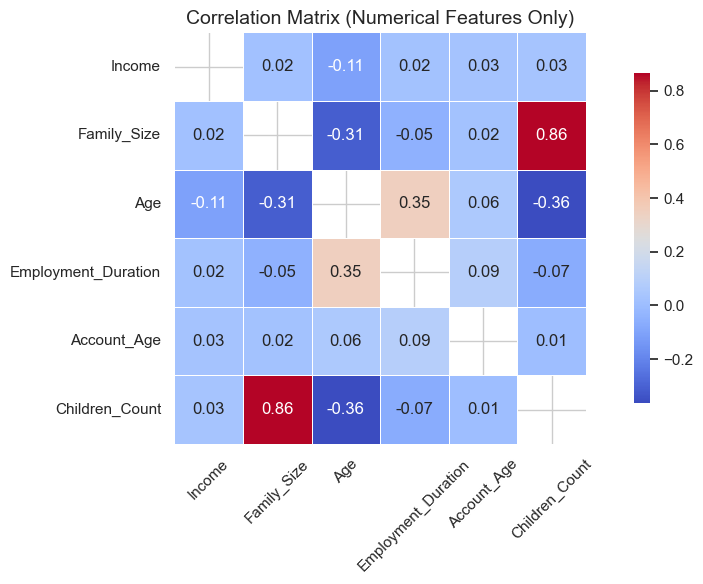

In [15]:

numerical_features = [
    'Income', 'Family_Size', 'Age',
    'Employment_Duration', 'Account_Age', 'Children_Count'
]

correlation_df = pd.DataFrame(index=numerical_features, columns=numerical_features)

for i, var1 in enumerate(numerical_features):
    for j, var2 in enumerate(numerical_features):
        mask = df_cleaned_iqr[[var1, var2]].dropna()
        vals1 = mask[var1].astype(float).values
        vals2 = mask[var2].astype(float).values
        if len(vals1) > 2 and np.unique(vals1).size > 1 and np.unique(vals2).size > 1:
            try:
                r, _ = pearsonr(vals1, vals2)
                correlation_df.at[var1, var2] = round(r, 4)
            except Exception as e:
                correlation_df.at[var1, var2] = np.nan
        else:
            correlation_df.at[var1, var2] = np.nan

correlation_df = correlation_df.astype(float)

print("Correlation Matrix (Numerical Features only):")
display(correlation_df)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Numerical Features Only)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()




In [16]:
# Load the cleaned dataset from CSV
df_clients_cleaned = pd.read_csv("df_clients_cleaned.csv")

# Optional: confirm it's loaded
print("Loaded shape:", df_clients_cleaned.shape)
print("Columns:", df_clients_cleaned.columns.tolist())


Loaded shape: (34455, 17)
Columns: ['ID', 'Gender', 'Owns_Car', 'Owns_Property', 'Children_Count', 'Income', 'Income_Type', 'Education_Level', 'Marital_Status', 'Housing_Type', 'Age', 'Employment_Duration', 'Occupation', 'Family_Size', 'Risk_Level', 'Account_Age', 'Is_Unemployed']


In [ ]:

from scipy.stats import chi2_contingency

crosstab = pd.crosstab(df_clients_cleaned['Gender'], df_clients_cleaned['Risk_Level'])
chi2, p, dof, expected = chi2_contingency(crosstab)

print("Chi-squared Statistic:", chi2)
print("p-value:", p)


Chi-squared Statistic: 12.708036368466356
p-value: 0.001739742466909486


In [ ]:
cross_tab = pd.crosstab(df_clients_cleaned['Gender'], df_clients_cleaned['Risk_Level'])
print(cross_tab)

Risk_Level      0     1    2
Gender                      
F           20745  2451  178
M            9689  1294   98


In [16]:
poly = PolynomialFeatures(degree=2, include_bias=False)

def add_features(df, poly_model=None, fit_poly=False, median_income=None):
    df = df.copy()
    df['Employment_Duration_FE'] = df['Employment_Duration'].fillna(0)
    
    # Interaction features
    df['Income_Family_Interaction'] = df['Income'] * df['Family_Size']
    df['Age_Income_Interaction'] = df['Age'] * df['Income']
    df['Employed_Income_Interaction'] = df['Employment_Duration_FE'] * df['Income']

    # Ratio features
    df['Income_Family_Ratio'] = df['Income'] / (df['Family_Size'] + 1e-6)
    df['Income_Age_Ratio'] = df['Income'] / (df['Age'] + 1e-6)
    df['Income_Employed_Ratio'] = df['Income'] / (df['Employment_Duration_FE'] + 1e-6)

    # Binned features
    df['Age_Bin'] = pd.cut(df['Age'], bins=5, labels=False)
    df['Income_Bin'] = pd.qcut(df['Income'], q=4, labels=False)

    # Polynomial features
    poly_input = df[['Income', 'Age', 'Employment_Duration_FE']]
    if fit_poly:
        poly_array = poly_model.fit_transform(poly_input)
    else:
        poly_array = poly_model.transform(poly_input)

    poly_df = pd.DataFrame(
        poly_array,
        columns=poly_model.get_feature_names_out(['Income', 'Age', 'Employment_Duration_FE']),
        index=df.index
    )
    df = pd.concat([df, poly_df], axis=1)
    df = df.loc[:, ~df.columns.duplicated()]

    if median_income is None:
        median_income = df['Income'].median()
    df['Income_Above_Median'] = (df['Income'] > median_income).astype(int)
    
    return df, median_income





In [17]:


# ==== Model input ====
df_model = df_clients_cleaned.copy()
X = df_model.drop(columns=['ID', 'Risk_Level'])
y = df_model['Risk_Level']

# ==== Split into train / val / test ====
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# ==== Feature Engineering ====
X_train_fe, income_median = add_features(X_train, poly_model=poly, fit_poly=True)
X_val_fe, _ = add_features(X_val, poly_model=poly, fit_poly=False, median_income=income_median)
X_test_fe, _ = add_features(X_test, poly_model=poly, fit_poly=False, median_income=income_median)


In [79]:

df = pd.read_csv("df_clients_cleaned.csv")

# Split
from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(df.index, test_size=0.2, stratify=df['Risk_Level'], random_state=42)
df.iloc[test_idx].to_csv("final_datasets/df_test_raw.csv", index=False)  # RAW test set (for fairness)
np.savetxt("final_datasets/test_indices.txt", test_idx, fmt='%d')



In [18]:
# ==== Encoding & Scaling ====
categorical_cols = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train_fe.select_dtypes(include=['number']).columns.tolist()

# One-hot encode
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train_fe[categorical_cols])
X_train_enc = encoder.transform(X_train_fe[categorical_cols])
X_val_enc = encoder.transform(X_val_fe[categorical_cols])
X_test_enc = encoder.transform(X_test_fe[categorical_cols])

X_train_enc_df = pd.DataFrame(X_train_enc, columns=encoder.get_feature_names_out(categorical_cols), index=X_train_fe.index)
X_val_enc_df = pd.DataFrame(X_val_enc, columns=encoder.get_feature_names_out(categorical_cols), index=X_val_fe.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=encoder.get_feature_names_out(categorical_cols), index=X_test_fe.index)

# Scale numeric
scaler = StandardScaler()
scaler.fit(X_train_fe[numerical_cols])
X_train_scaled = scaler.transform(X_train_fe[numerical_cols])
X_val_scaled = scaler.transform(X_val_fe[numerical_cols])
X_test_scaled = scaler.transform(X_test_fe[numerical_cols])

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train_fe.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=numerical_cols, index=X_val_fe.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test_fe.index)

# ==== Final datasets ====
X_train_final = pd.concat([X_train_enc_df, X_train_scaled_df], axis=1)
X_val_final = pd.concat([X_val_enc_df, X_val_scaled_df], axis=1)
X_test_final = pd.concat([X_test_enc_df, X_test_scaled_df], axis=1)

# ==== Correct column renaming for true mapping (binary flags) ====
rename_dict = {
    'Owns_Car_Y': 'Owns_Car_YES',      # Y = 1 means owns a car
    'Owns_Car_N': 'Owns_Car_NO',       # N = 1 means does not own a car
    'Owns_Property_Y': 'Owns_Property_YES',
    'Owns_Property_N': 'Owns_Property_NO'
}
X_train_final = X_train_final.rename(columns=rename_dict)
X_val_final = X_val_final.rename(columns=rename_dict)
X_test_final = X_test_final.rename(columns=rename_dict)

# ==== (Optional) Sanity check for encoding ====
# Check if encoding is correct for a few rows
sample_idx = X_train_fe.index[:5]
print("Raw values:")
print(X_train_fe.loc[sample_idx, ['Owns_Car', 'Owns_Property']])
print("Encoded values:")
print(X_train_final.loc[sample_idx, ['Owns_Car_YES', 'Owns_Car_NO', 'Owns_Property_YES', 'Owns_Property_NO']])

# ==== Class Distribution Reporting ====
print("\n=== Class Counts in Each Set ===")
print("Train set counts:\n", y_train.value_counts())
print("Validation set counts:\n", y_val.value_counts())
print("Test set counts:\n", y_test.value_counts())

print("\n=== Class Distribution (Proportion) ===")
print("Train set proportion:\n", y_train.value_counts(normalize=True).round(4))
print("Validation set proportion:\n", y_val.value_counts(normalize=True).round(4))
print("Test set proportion:\n", y_test.value_counts(normalize=True).round(4))



OneHotEncoder(handle_unknown='ignore', sparse_output=False)

StandardScaler()

Raw values:
      Owns_Car Owns_Property
31708        N             N
20841        N             Y
20102        N             N
26176        N             N
32536        N             N
Encoded values:
       Owns_Car_YES  Owns_Car_NO  Owns_Property_YES  Owns_Property_NO
31708           0.0          1.0                0.0               1.0
20841           0.0          1.0                1.0               0.0
20102           0.0          1.0                0.0               1.0
26176           0.0          1.0                0.0               1.0
32536           0.0          1.0                0.0               1.0

=== Class Counts in Each Set ===
Train set counts:
 Risk_Level
0    21303
1     2622
2      193
Name: count, dtype: int64
Validation set counts:
 Risk_Level
0    4565
1     561
2      42
Name: count, dtype: int64
Test set counts:
 Risk_Level
0    4566
1     562
2      41
Name: count, dtype: int64

=== Class Distribution (Proportion) ===
Train set proportion:
 Risk_Level
0   

CatBoost class_weights: [0.37738033766762114, 3.0661072972285788, 41.6545768566494]

Training: Logistic Regression
F1 Score (CV Mean): 0.2776


Pipeline(steps=[('imputer', SimpleImputer(fill_value=0, strategy='constant')),
                ('adasyn', ADASYN(n_neighbors=3, random_state=42)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    random_state=42))])


Classification Report:
              precision    recall  f1-score   support

           0     0.9061    0.4524    0.6034      4565
           1     0.1233    0.3351    0.1802       561
           2     0.0176    0.5714    0.0341        42

    accuracy                         0.4406      5168
   macro avg     0.3490    0.4530    0.2726      5168
weighted avg     0.8139    0.4406    0.5529      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

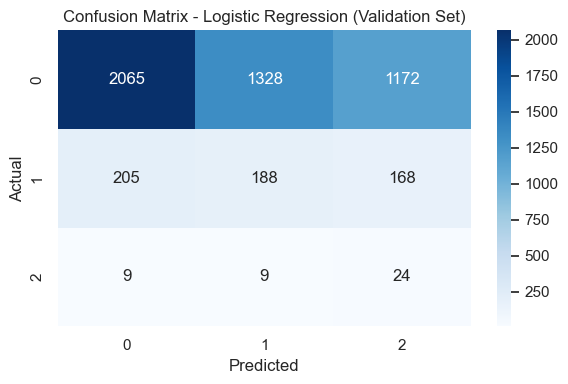

Recall for High Risk (class 2): 0.5714
F1 Score (Validation): 0.2726
AUC-ROC (OVR, Validation): 0.5933
Average Precision (Macro, PRC): 0.3486


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - Logistic Regression')

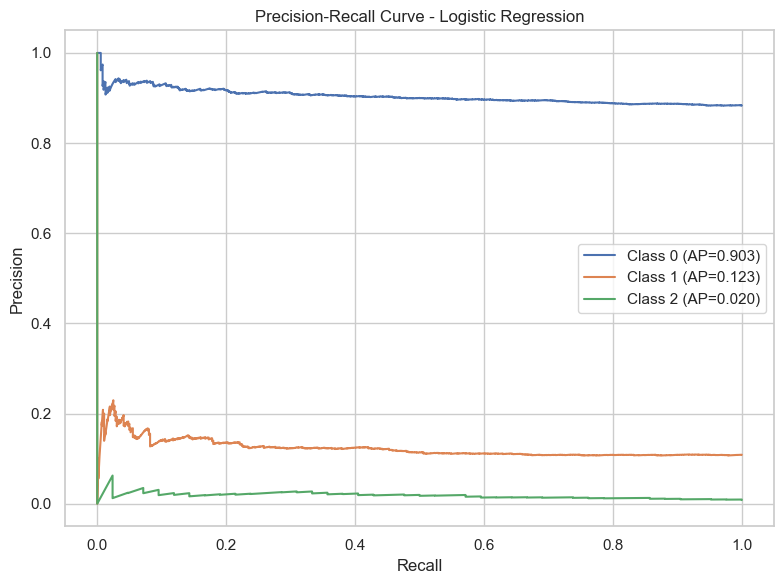


Training: Random Forest
F1 Score (CV Mean): 0.5107


Pipeline(steps=[('imputer', SimpleImputer(fill_value=0, strategy='constant')),
                ('adasyn', ADASYN(n_neighbors=3, random_state=42)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])


Classification Report:
              precision    recall  f1-score   support

           0     0.9193    0.9352    0.9271      4565
           1     0.4259    0.3690    0.3954       561
           2     0.3421    0.3095    0.3250        42

    accuracy                         0.8686      5168
   macro avg     0.5624    0.5379    0.5492      5168
weighted avg     0.8610    0.8686    0.8645      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

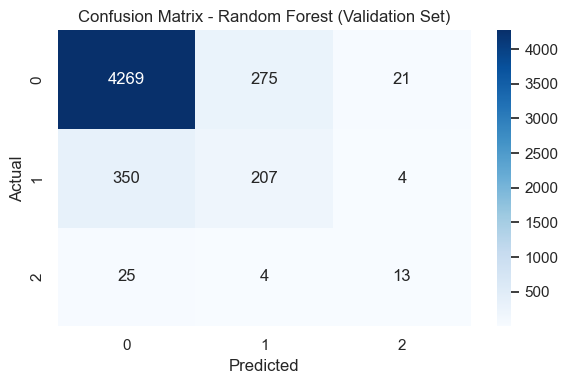

Recall for High Risk (class 2): 0.3095
F1 Score (Validation): 0.5492
AUC-ROC (OVR, Validation): 0.7648
Average Precision (Macro, PRC): 0.4900


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - Random Forest')

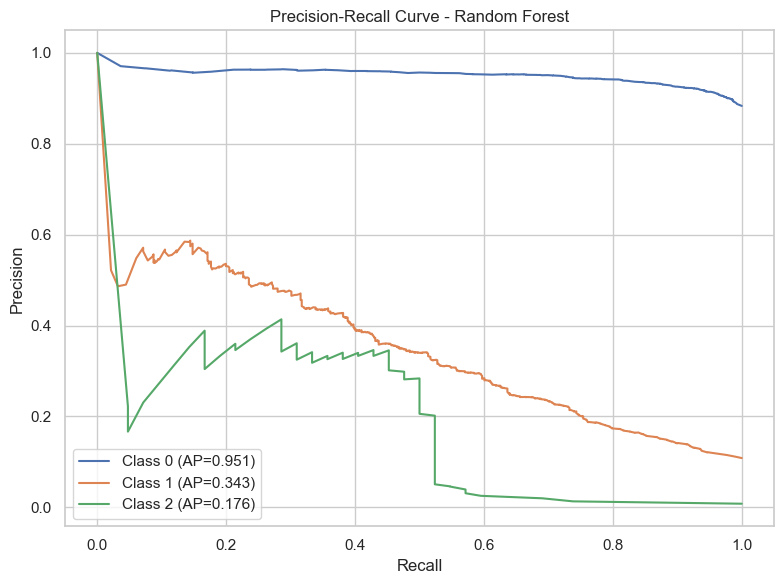


Training: Gradient Boosting
F1 Score (CV Mean): 0.3831


Pipeline(steps=[('imputer', SimpleImputer(fill_value=0, strategy='constant')),
                ('adasyn', ADASYN(n_neighbors=3, random_state=42)),
                ('clf',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])


Classification Report:
              precision    recall  f1-score   support

           0     0.8912    0.9078    0.8994      4565
           1     0.1814    0.1283    0.1503       561
           2     0.0661    0.1905    0.0982        42

    accuracy                         0.8173      5168
   macro avg     0.3796    0.4089    0.3826      5168
weighted avg     0.8074    0.8173    0.8116      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Gradient Boosting (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

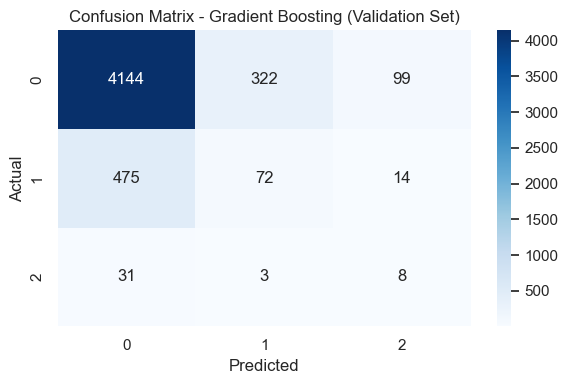

Recall for High Risk (class 2): 0.1905
F1 Score (Validation): 0.3826
AUC-ROC (OVR, Validation): 0.6600
Average Precision (Macro, PRC): 0.3941


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - Gradient Boosting')

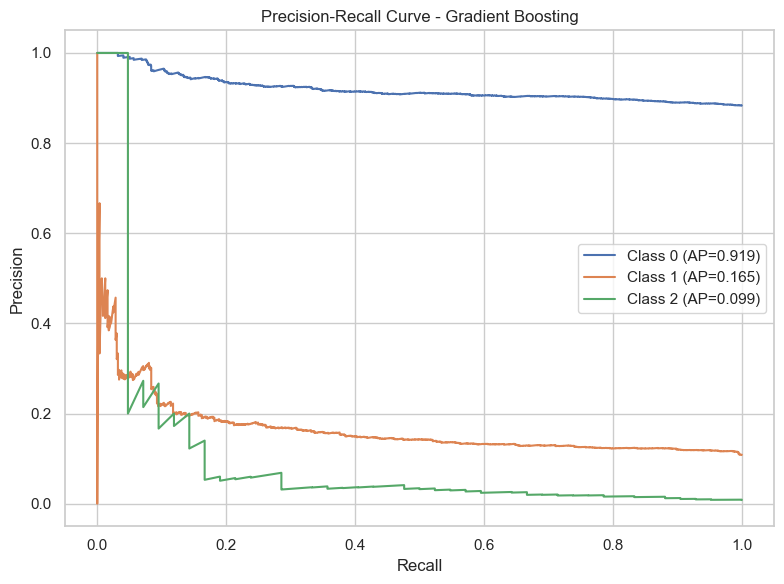


Training: XGBoost
F1 Score (CV Mean): 0.4587


Pipeline(steps=[('imputer', SimpleImputer(fill_value=0, strategy='constant')),
                ('adasyn', ADASYN(n_neighbors=3, random_state=42)),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               featur...ne,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])


Classification Report:
              precision    recall  f1-score   support

           0     0.9030    0.9610    0.9311      4565
           1     0.4248    0.2014    0.2733       561
           2     0.2955    0.3095    0.3023        42

    accuracy                         0.8733      5168
   macro avg     0.5411    0.4907    0.5022      5168
weighted avg     0.8462    0.8733    0.8546      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - XGBoost (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

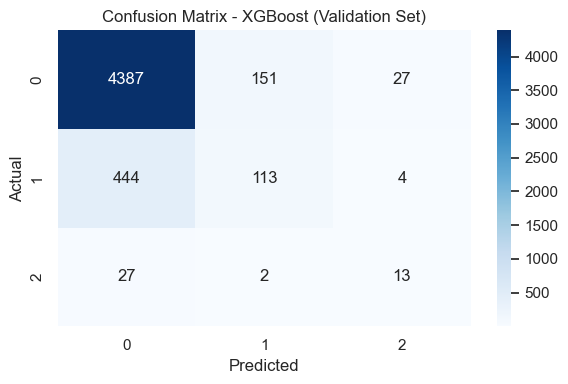

Recall for High Risk (class 2): 0.3095
F1 Score (Validation): 0.5022
AUC-ROC (OVR, Validation): 0.7242
Average Precision (Macro, PRC): 0.4582


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - XGBoost')

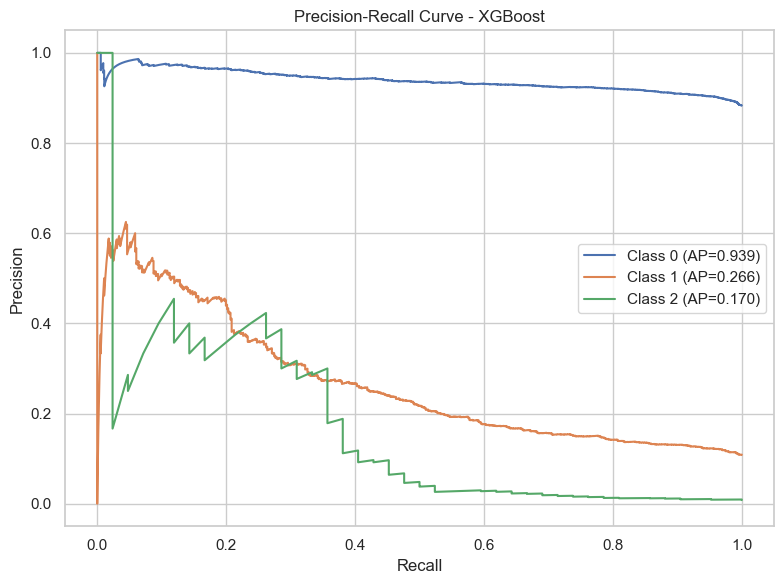


Training: LightGBM
F1 Score (CV Mean): 0.4134
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009960 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15699
[LightGBM] [Info] Number of data points in the train set: 63681, number of used features: 68
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


Pipeline(steps=[('imputer', SimpleImputer(fill_value=0, strategy='constant')),
                ('adasyn', ADASYN(n_neighbors=3, random_state=42)),
                ('clf',
                 LGBMClassifier(class_weight='balanced', random_state=42))])


Classification Report:
              precision    recall  f1-score   support

           0     0.8955    0.9691    0.9309      4565
           1     0.3977    0.1248    0.1900       561
           2     0.2308    0.2857    0.2553        42

    accuracy                         0.8719      5168
   macro avg     0.5080    0.4599    0.4587      5168
weighted avg     0.8361    0.8719    0.8450      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - LightGBM (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

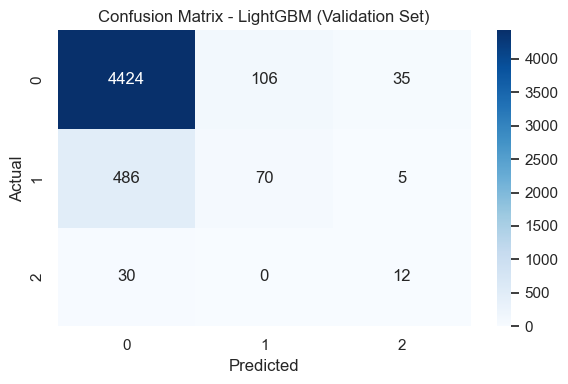

Recall for High Risk (class 2): 0.2857
F1 Score (Validation): 0.4587
AUC-ROC (OVR, Validation): 0.6972
Average Precision (Macro, PRC): 0.4323


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - LightGBM')

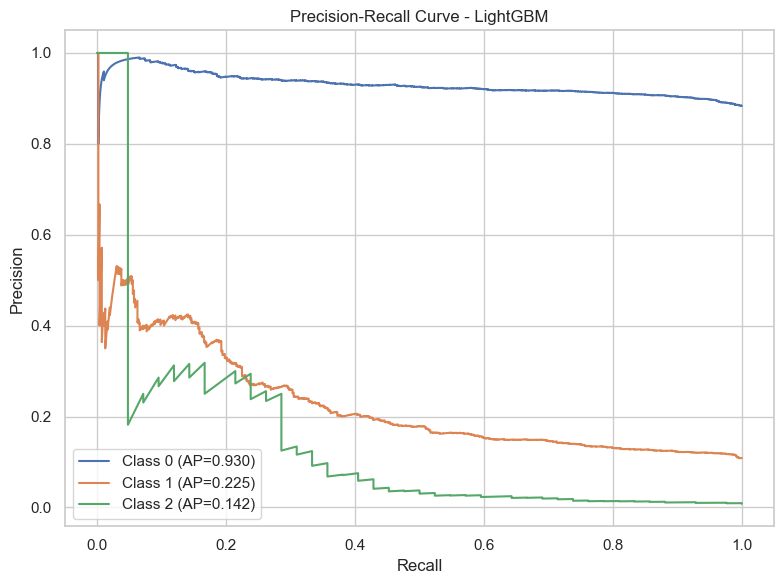


Training: CatBoost
F1 Score (CV Mean): 0.2124


Pipeline(steps=[('imputer', SimpleImputer(fill_value=0, strategy='constant')),
                ('adasyn', ADASYN(n_neighbors=3, random_state=42)),
                ('clf',
                 <catboost.core.CatBoostClassifier object at 0x000001CE2776BCE0>)])


Classification Report:
              precision    recall  f1-score   support

           0     0.9728    0.1880    0.3150      4565
           1     0.1283    0.8984    0.2246       561
           2     0.0613    0.5238    0.1097        42

    accuracy                         0.2678      5168
   macro avg     0.3875    0.5367    0.2165      5168
weighted avg     0.8737    0.2678    0.3036      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - CatBoost (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

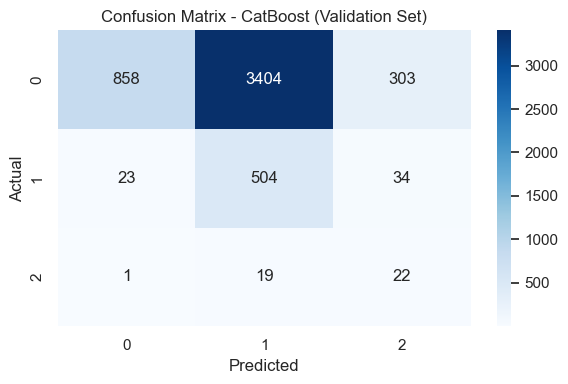

Recall for High Risk (class 2): 0.5238
F1 Score (Validation): 0.2165
AUC-ROC (OVR, Validation): 0.6846
Average Precision (Macro, PRC): 0.4168


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - CatBoost')

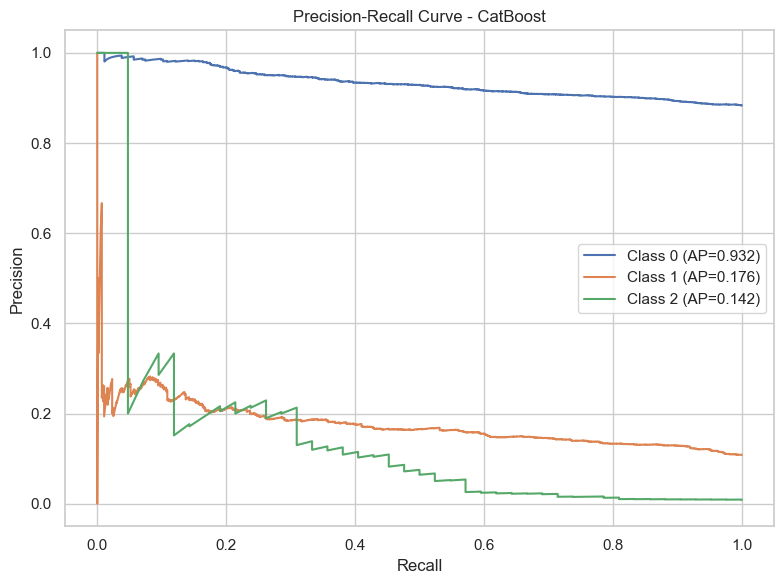

In [21]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, recall_score

# --- Calculate CatBoost class weights based on y_train ---
class_counts = y_train.value_counts().sort_index()
total = len(y_train)
catboost_weights = [total / (3 * class_counts[i]) for i in [0, 1, 2]]
print("CatBoost class_weights:", catboost_weights)

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42),
    "CatBoost": CatBoostClassifier(class_weights=catboost_weights, verbose=0, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining: {name}")

    pipe = ImbPipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
        ('clf', model)
    ])

    # Cross-validated F1 Macro (5-fold)
    cv_f1 = cross_val_score(pipe, X_train_final, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    print(f"F1 Score (CV Mean): {cv_f1.mean():.4f}")

    # Fit model on train set
    pipe.fit(X_train_final, y_train)
    y_pred = pipe.predict(X_val_final)
    y_prob = pipe.predict_proba(X_val_final)

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, digits=4))

    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name} (Validation Set)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Metrics
    f1_val = f1_score(y_val, y_pred, average='macro')
    auc_val = roc_auc_score(y_val, y_prob, multi_class='ovr')
    avg_precision = average_precision_score(y_val, y_prob, average='macro')

    # === Recall for class 2 only ===
    recall_per_class = recall_score(y_val, y_pred, average=None, labels=[0, 1, 2])
    recall_class_2 = recall_per_class[2] if len(recall_per_class) > 2 else float('nan')
    print(f"Recall for High Risk (class 2): {recall_class_2:.4f}")

    print(f"F1 Score (Validation): {f1_val:.4f}")
    print(f"AUC-ROC (OVR, Validation): {auc_val:.4f}")
    print(f"Average Precision (Macro, PRC): {avg_precision:.4f}")

    # Precision-Recall Curve per class
    y_val_bin = label_binarize(y_val, classes=[0, 1, 2])
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate([0, 1, 2]):
        precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_prob[:, i])
        ap = average_precision_score(y_val_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, label=f"Class {class_label} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Save results
    results[name] = {
        "model": pipe,
        "cv_f1_macro": cv_f1.mean(),
        "f1_macro_val": f1_val,
        "auc_roc_val": auc_val,
        "avg_precision_macro": avg_precision,
        "recall_class_2": recall_class_2,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


CatBoost class_weights: [0.37738033766762114, 3.0661072972285788, 41.6545768566494]

Training: Logistic Regression


Pipeline(steps=[('imputer', SimpleImputer()), ('smote', SMOTE(random_state=42)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    random_state=42))])


Classification Report:
              precision    recall  f1-score   support

           0     0.9084    0.4519    0.6036      4565
           1     0.1340    0.3725    0.1971       561
           2     0.0157    0.5000    0.0305        42

    accuracy                         0.4437      5168
   macro avg     0.3527    0.4415    0.2770      5168
weighted avg     0.8171    0.4437    0.5548      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

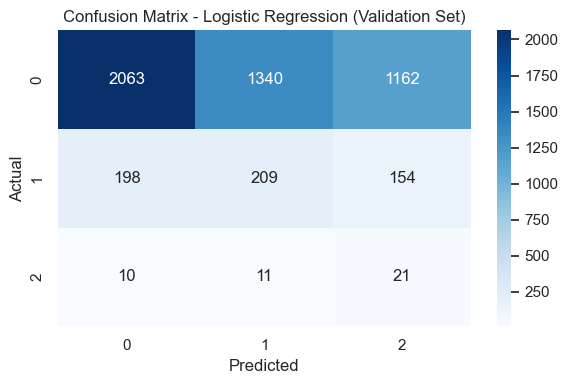

Recall for High Risk (class 2): 0.5000
F1 Score (CV Mean): 0.2797
F1 Score (Validation): 0.2770
AUC-ROC (OVR, Validation): 0.5960
Average Precision (Macro, PRC): 0.3503


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - Logistic Regression')

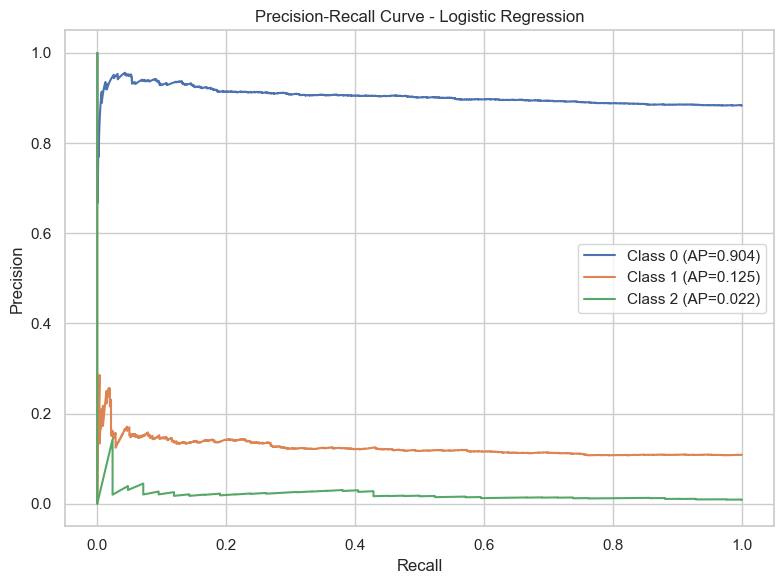


Training: Random Forest


Pipeline(steps=[('imputer', SimpleImputer()), ('smote', SMOTE(random_state=42)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])


Classification Report:
              precision    recall  f1-score   support

           0     0.9193    0.9363    0.9277      4565
           1     0.4286    0.3690    0.3966       561
           2     0.3333    0.2857    0.3077        42

    accuracy                         0.8694      5168
   macro avg     0.5604    0.5303    0.5440      5168
weighted avg     0.8613    0.8694    0.8650      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

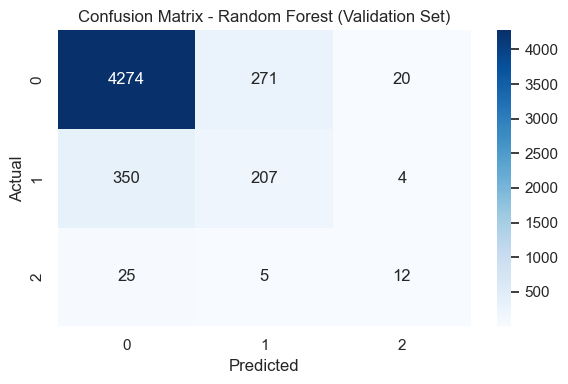

Recall for High Risk (class 2): 0.2857
F1 Score (CV Mean): 0.5126
F1 Score (Validation): 0.5440
AUC-ROC (OVR, Validation): 0.7733
Average Precision (Macro, PRC): 0.4973


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - Random Forest')

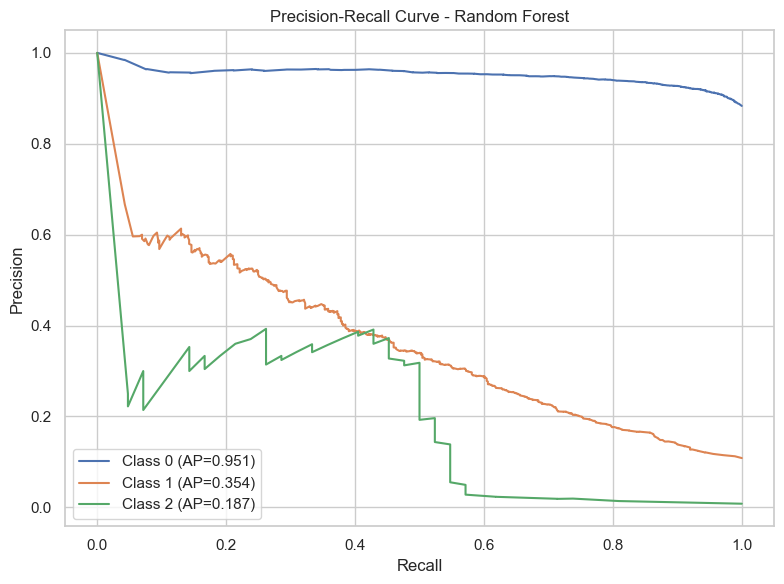


Training: Gradient Boosting


Pipeline(steps=[('imputer', SimpleImputer()), ('smote', SMOTE(random_state=42)),
                ('clf',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])


Classification Report:
              precision    recall  f1-score   support

           0     0.8948    0.9295    0.9118      4565
           1     0.2543    0.1586    0.1954       561
           2     0.0789    0.1429    0.1017        42

    accuracy                         0.8394      5168
   macro avg     0.4093    0.4103    0.4030      5168
weighted avg     0.8186    0.8394    0.8274      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Gradient Boosting (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

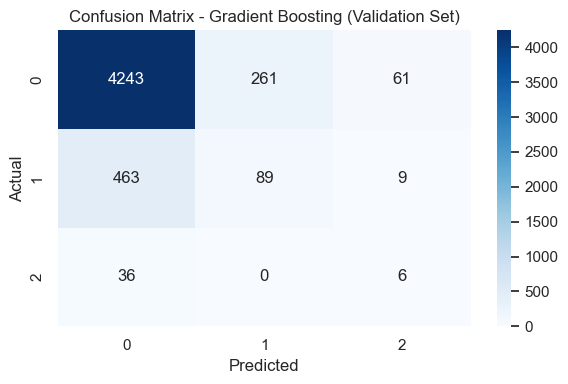

Recall for High Risk (class 2): 0.1429
F1 Score (CV Mean): 0.3821
F1 Score (Validation): 0.4030
AUC-ROC (OVR, Validation): 0.6733
Average Precision (Macro, PRC): 0.4065


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - Gradient Boosting')

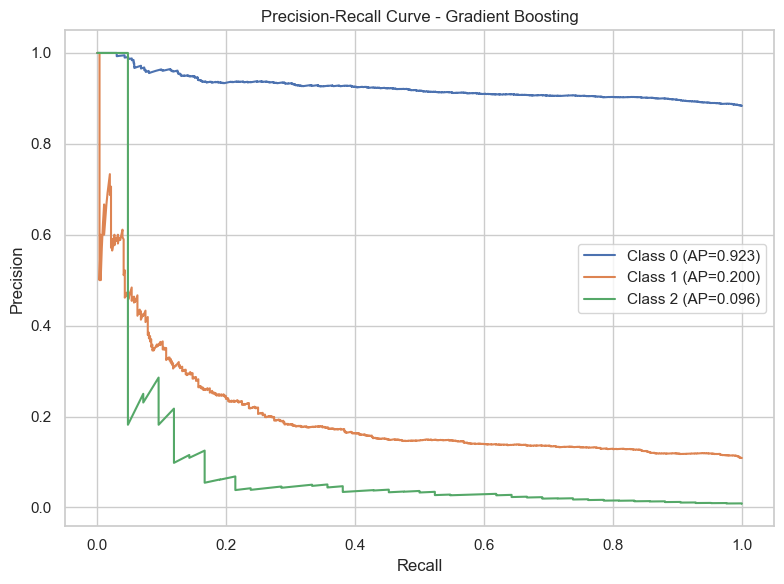


Training: XGBoost


Pipeline(steps=[('imputer', SimpleImputer()), ('smote', SMOTE(random_state=42)),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])


Classification Report:
              precision    recall  f1-score   support

           0     0.9026    0.9628    0.9317      4565
           1     0.4353    0.1979    0.2721       561
           2     0.2727    0.2857    0.2791        42

    accuracy                         0.8742      5168
   macro avg     0.5369    0.4821    0.4943      5168
weighted avg     0.8468    0.8742    0.8548      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - XGBoost (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

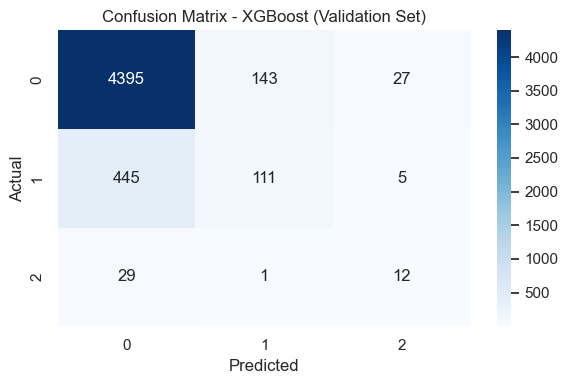

Recall for High Risk (class 2): 0.2857
F1 Score (CV Mean): 0.4589
F1 Score (Validation): 0.4943
AUC-ROC (OVR, Validation): 0.7304
Average Precision (Macro, PRC): 0.4654


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - XGBoost')

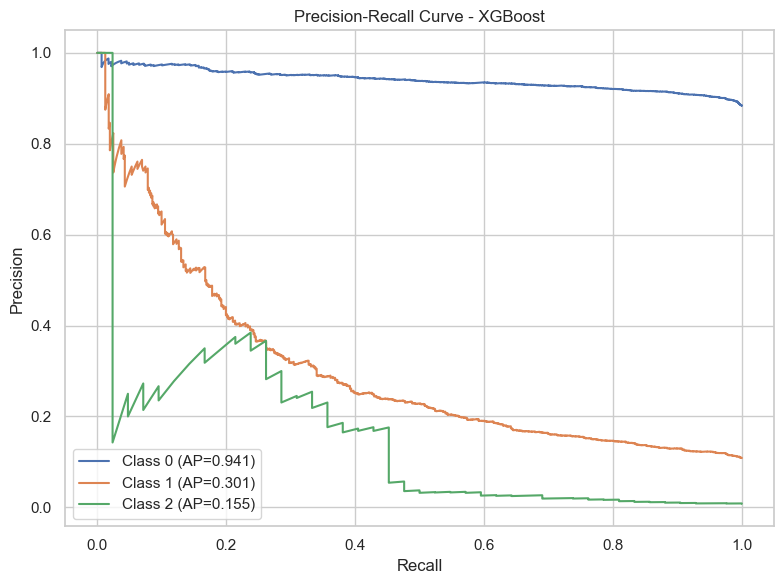


Training: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15988
[LightGBM] [Info] Number of data points in the train set: 63909, number of used features: 68
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


Pipeline(steps=[('imputer', SimpleImputer()), ('smote', SMOTE(random_state=42)),
                ('clf',
                 LGBMClassifier(class_weight='balanced', random_state=42))])


Classification Report:
              precision    recall  f1-score   support

           0     0.8965    0.9768    0.9349      4565
           1     0.4771    0.1301    0.2045       561
           2     0.2683    0.2619    0.2651        42

    accuracy                         0.8791      5168
   macro avg     0.5473    0.4563    0.4681      5168
weighted avg     0.8458    0.8791    0.8502      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - LightGBM (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

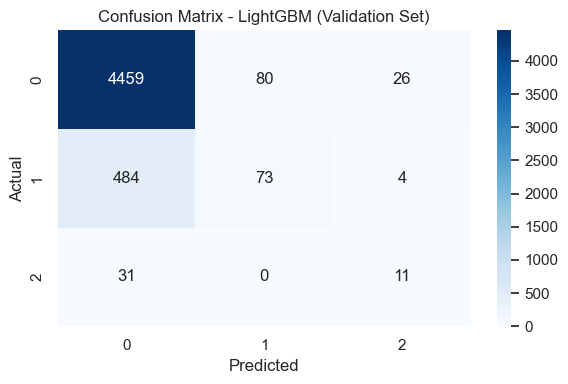

Recall for High Risk (class 2): 0.2619
F1 Score (CV Mean): 0.4091
F1 Score (Validation): 0.4681
AUC-ROC (OVR, Validation): 0.7055
Average Precision (Macro, PRC): 0.4493


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - LightGBM')

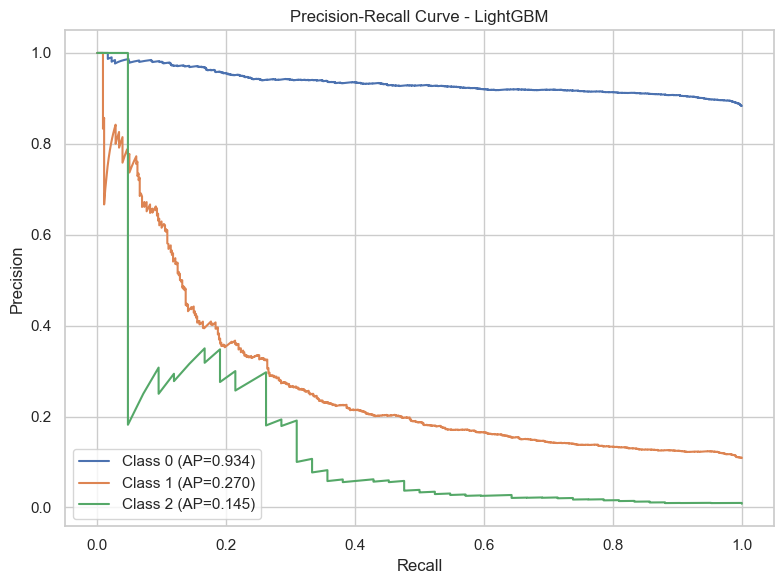


Training: CatBoost


Pipeline(steps=[('imputer', SimpleImputer()), ('smote', SMOTE(random_state=42)),
                ('clf',
                 <catboost.core.CatBoostClassifier object at 0x000001CE2D38A0F0>)])


Classification Report:
              precision    recall  f1-score   support

           0     0.9543    0.2151    0.3511      4565
           1     0.1286    0.8610    0.2238       561
           2     0.0547    0.5000    0.0986        42

    accuracy                         0.2875      5168
   macro avg     0.3792    0.5254    0.2245      5168
weighted avg     0.8574    0.2875    0.3352      5168



<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - CatBoost (Validation Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(42.25, 0.5, 'Actual')

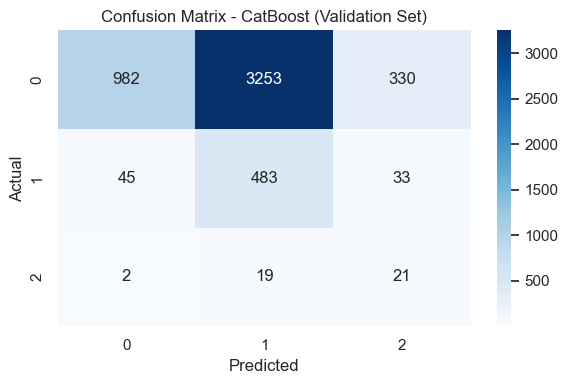

Recall for High Risk (class 2): 0.5000
F1 Score (CV Mean): 0.2164
F1 Score (Validation): 0.2245
AUC-ROC (OVR, Validation): 0.6884
Average Precision (Macro, PRC): 0.4248


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve - CatBoost')

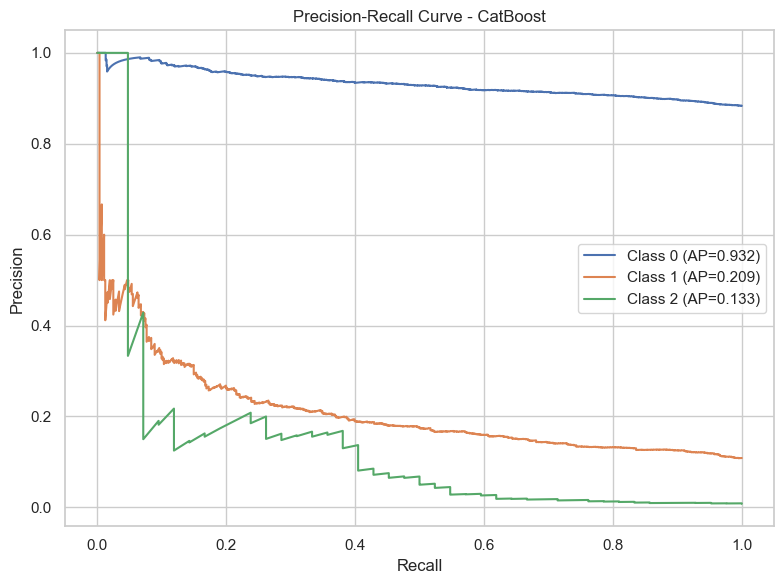

In [22]:

# --- Calculate CatBoost class weights based on y_train ---
class_counts = y_train.value_counts().sort_index()
total = len(y_train)
catboost_weights = [total / (3 * class_counts[i]) for i in [0, 1, 2]]
print("CatBoost class_weights:", catboost_weights)

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42),
    "CatBoost": CatBoostClassifier(class_weights=catboost_weights, verbose=0, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining: {name}")

    pipe = ImbPipeline([
        ('imputer', SimpleImputer(strategy='mean')),  
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])

    # Cross-validated F1 Macro (5-fold)
    cv_f1 = cross_val_score(pipe, X_train_final, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    

    # Fit model on train set
    pipe.fit(X_train_final, y_train)
    y_pred = pipe.predict(X_val_final)
    y_prob = pipe.predict_proba(X_val_final)

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, digits=4))

    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name} (Validation Set)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Metrics
    f1_val = f1_score(y_val, y_pred, average='macro')
    auc_val = roc_auc_score(y_val, y_prob, multi_class='ovr')
    avg_precision = average_precision_score(y_val, y_prob, average='macro')


    # === Recall for class 2 only ===
    recall_per_class = recall_score(y_val, y_pred, average=None, labels=[0, 1, 2])
    recall_class_2 = recall_per_class[2] if len(recall_per_class) > 2 else float('nan')
    print(f"Recall for High Risk (class 2): {recall_class_2:.4f}")
    print(f"F1 Score (CV Mean): {cv_f1.mean():.4f}")
    print(f"F1 Score (Validation): {f1_val:.4f}")
    print(f"AUC-ROC (OVR, Validation): {auc_val:.4f}")
    print(f"Average Precision (Macro, PRC): {avg_precision:.4f}")

    # Precision-Recall Curve per class
    y_val_bin = label_binarize(y_val, classes=[0, 1, 2])
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate([0, 1, 2]):
        precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_prob[:, i])
        ap = average_precision_score(y_val_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, label=f"Class {class_label} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Save results
    results[name] = {
        "model": pipe,
        "cv_f1_macro": cv_f1.mean(),
        "f1_macro_val": f1_val,
        "auc_roc_val": auc_val,
        "avg_precision_macro": avg_precision,
        "recall_class_2": recall_class_2,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [25]:

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# ---- Cross-validation strategy ----
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- CatBoost class weights ----
class_counts = y_train.value_counts().sort_index()
total = len(y_train)
catboost_weights = [total / (3 * class_counts[i]) for i in [0, 1, 2]]

# ---- Pipeline Creators ----
def pipeline_with_smote(model):
    return ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(sampling_strategy={1: 4000, 2: 600}, random_state=42)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

def pipeline_no_smote(model):
    return ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

# ---- Param Grids ----

# Random Forest (GridSearchCV)
rf_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [15, 20, 25],
    'model__min_samples_split': [2, 3],
    'model__min_samples_leaf': [1, 2, 0.01, 0.05],
    'model__class_weight': [
        None,
        'balanced',
        'balanced_subsample',
        {0: 1, 1: 10, 2: 100},
    ]
}
rf_model = RandomForestClassifier(random_state=42)

# BalancedRandomForest (GridSearchCV, NO SMOTE)
brf_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [15, 20, 25],
    'model__min_samples_split': [2, 3],
    'model__min_samples_leaf': [1, 2, 0.01, 0.05],
}
brf_model = BalancedRandomForestClassifier(random_state=42)

# XGBoost (GridSearchCV)
xgb_param_grid = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [7, 8, 9],
    'model__learning_rate': [0.3, 0.5, 0.6],
    'model__scale_pos_weight': [1, 10, 100],
    'model__subsample': [0.3, 0.4, 0.5, 0.6],
    'model__colsample_bytree': [0.8, 1.0],
}
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    tree_method='hist'
)

# AdaBoost (GridSearchCV)
adaboost_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__estimator': [DecisionTreeClassifier(max_depth=2), DecisionTreeClassifier(max_depth=3)],
    'model__learning_rate': [0.5, 1.0]
}
adaboost_model = AdaBoostClassifier(random_state=42)

# LightGBM (RandomizedSearchCV)
lgbm_param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.1, 0.2, 0.3],
    'model__max_depth': [5, 7, 8, 9],
    'model__num_leaves': [31, 50, 70],
    'model__subsample': [0.8, 1.0]
}
lgbm_model = LGBMClassifier(class_weight='balanced', random_state=42)

# Gradient Boosting (RandomizedSearchCV)
gb_param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.1, 0.2, 0.3],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.6, 0.8, 1.0]
}
gb_model = GradientBoostingClassifier(random_state=42)

# Logistic Regression (RandomizedSearchCV)
lr_param_dist = {
    'model__C': [0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['liblinear']
}
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# CatBoost (RandomizedSearchCV)
catboost_param_dist = {
    'model__iterations': [100, 200, 300],
    'model__depth': [5, 7, 8, 9],
    'model__learning_rate': [0.1, 0.2, 0.3]
}
catboost_model = CatBoostClassifier(
    class_weights=catboost_weights,
    verbose=0,
    random_state=42
)

# ---- Search objects ----
search_objects = {
    'Random Forest': GridSearchCV(
        pipeline_with_smote(rf_model),
        param_grid=rf_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1
    ),
    'Balanced Random Forest': GridSearchCV(
        pipeline_no_smote(brf_model),
        param_grid=brf_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1
    ),
    'XGBoost': GridSearchCV(
        pipeline_with_smote(xgb_model),
        param_grid=xgb_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1
    ),
    'AdaBoost': GridSearchCV(
        pipeline_with_smote(adaboost_model),
        param_grid=adaboost_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1
    ),
    'LightGBM': RandomizedSearchCV(
        pipeline_with_smote(lgbm_model),
        param_distributions=lgbm_param_dist,
        n_iter=10,
        cv=cv_strategy,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1,
        random_state=42
    ),
    'Gradient Boosting': RandomizedSearchCV(
        pipeline_with_smote(gb_model),
        param_distributions=gb_param_dist,
        n_iter=10,
        cv=cv_strategy,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1,
        random_state=42
    ),
    'Logistic Regression': RandomizedSearchCV(
        pipeline_with_smote(lr_model),
        param_distributions=lr_param_dist,
        n_iter=10,
        cv=cv_strategy,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1,
        random_state=42
    ),
    'CatBoost': RandomizedSearchCV(
        pipeline_with_smote(catboost_model),
        param_distributions=catboost_param_dist,
        n_iter=10,
        cv=cv_strategy,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1,
        random_state=42
    ),
}

# ---- Run searches and collect optimized models ----
optimized_models = {}
for name, search in search_objects.items():
    print(f"\nOptimizing: {name}")
    search.fit(X_train_final, y_train)
    optimized_models[name] = search.best_estimator_
    print(f"Best params for {name}:", search.best_params_)



Optimizing: Random Forest
Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('smote',
                                        SMOTE(random_state=42,
                                              sampling_strategy={1: 4000,
                                                                 2: 600})),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced',
                                                 'balanced_subsample',
                                                 {0: 1, 1: 10, 2: 100}],
                         'model__max_depth': [15, 20, 25],
                         'model__min_samples_leaf': [1, 2, 0.01, 0.05],
                         'model__min_samples_split': [2, 3],
                         'model__n_estimators': [50, 100, 150]},
             scoring='f1_macro', verbose=2)

Best params for Random Forest: {'model__class_weight': 'balanced', 'model__max_depth': 25, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Optimizing: Balanced Random Forest
Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        BalancedRandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [15, 20, 25],
                         'model__min_samples_leaf': [1, 2, 0.01, 0.05],
                         'model__min_samples_split': [2, 3],
                         'model__n_estimators': [50, 100, 150]},
             scoring='f1_macro', verbose=2)

Best params for Balanced Random Forest: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 150}

Optimizing: XGBoost
Fitting 5 folds for each of 648 candidates, totalling 3240 fits


...

Best params for Gradient Boosting: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.3}

Optimizing: Logistic Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('smote',
                                              SMOTE(random_state=42,
                                                    sampling_strategy={1: 4000,
                                                                       2: 600})),
                                             ('scaler', StandardScaler()),
                                             ('model',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=1000,
                                                                 random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__C': [0.1, 1, 10, 100],
                                        'model__penalty': ['l2'],
                                        'model__solver': ['liblinear']},
                   random_state=42, scoring='f1_macro', verbose=2)

Best params for Logistic Regression: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 100}

Optimizing: CatBoost
Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('smote',
                                              SMOTE(random_state=42,
                                                    sampling_strategy={1: 4000,
                                                                       2: 600})),
                                             ('scaler', StandardScaler()),
                                             ('model',
                                              <catboost.core.CatBoostClassifier object at 0x000001CE281068A0>)]),
                   n_jobs=-1,
                   param_distributions={'model__depth': [5, 7, 8, 9],
                                        'model__iterations': [100, 200, 300],
                                        'model__learning_rate': [0.1, 0.2,
                                                                 0.3]},
                   random_state=42, scoring='f1_macro', verbose=2)

Best params for CatBoost: {'model__learning_rate': 0.3, 'model__iterations': 300, 'model__depth': 9}


In [27]:


# Create a folder for saving models (if it doesn't already exist)
os.makedirs("saved_models", exist_ok=True)

# Save each optimized model
for name, model in optimized_models.items():
    filename = f"saved_models/{name.replace(' ', '_').lower()}_optimized.pkl"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")


print("All optimized models saved successfully to 'saved_models/' folder.")



['saved_models/random_forest_optimized.pkl']

Saved: saved_models/random_forest_optimized.pkl


['saved_models/balanced_random_forest_optimized.pkl']

Saved: saved_models/balanced_random_forest_optimized.pkl


['saved_models/xgboost_optimized.pkl']

...

Saved: saved_models/gradient_boosting_optimized.pkl


['saved_models/logistic_regression_optimized.pkl']

Saved: saved_models/logistic_regression_optimized.pkl


['saved_models/catboost_optimized.pkl']

Saved: saved_models/catboost_optimized.pkl
All optimized models saved successfully to 'saved_models/' folder.


In [29]:
from sklearn.metrics import precision_score

for name, model in optimized_models.items():
    print(f"\n=== {name} (Validation Set - After Hyperparameter Tuning) ===")
    y_pred = model.predict(X_val_final)
    y_prob = model.predict_proba(X_val_final)
    print(classification_report(y_val, y_pred, digits=4))
    print("F1 Macro:", f1_score(y_val, y_pred, average='macro'))
    print("AUC-ROC:", roc_auc_score(y_val, y_prob, multi_class='ovr'))
    print("AP Macro:", average_precision_score(y_val, y_prob, average='macro'))
    print("Recall (Class 2):", recall_score(y_val, y_pred, labels=[2], average=None)[0])
    print("Precision (Class 2):", precision_score(y_val, y_pred, labels=[2], average=None)[0])


=== Random Forest (Validation Set - After Hyperparameter Tuning) ===
              precision    recall  f1-score   support

           0     0.9174    0.9387    0.9279      4565
           1     0.4356    0.3494    0.3877       561
           2     0.2979    0.3333    0.3146        42

    accuracy                         0.8698      5168
   macro avg     0.5503    0.5405    0.5434      5168
weighted avg     0.8600    0.8698    0.8643      5168

F1 Macro: 0.5434108397809383
AUC-ROC: 0.7790397357741435
AP Macro: 0.518021973151023
Recall (Class 2): 0.3333333333333333
Precision (Class 2): 0.2978723404255319

=== Balanced Random Forest (Validation Set - After Hyperparameter Tuning) ===
              precision    recall  f1-score   support

           0     0.9331    0.5831    0.7177      4565
           1     0.1745    0.5668    0.2669       561
           2     0.0467    0.5476    0.0860        42

    accuracy                         0.5811      5168
   macro avg     0.3847    0.5659   


Best threshold for class 2 (High Risk, validation): 0.570
Best F1 (class 2, val): 0.3056
Precision: 0.3667, Recall: 0.2619


<Figure size 700x400 with 0 Axes>

Text(0.5, 0, 'Threshold for Class 2 (High Risk)')

Text(0, 0.5, 'F1 Score (Class 2)')

Text(0.5, 1.0, 'Threshold Tuning for Class 2 - XGBoost (Validation Set)')

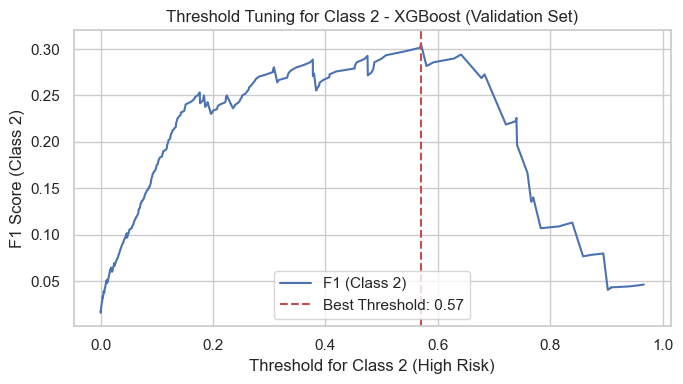


Threshold for recall >= 0.30 (validation): 0.00
F1: 0.0161, Precision: 0.0081, Recall: 1.0000

Classification report (default multiclass argmax, val):
              precision    recall  f1-score   support

           0     0.9026    0.9628    0.9317      4565
           1     0.4353    0.1979    0.2721       561
           2     0.2727    0.2857    0.2791        42

    accuracy                         0.8742      5168
   macro avg     0.5369    0.4821    0.4943      5168
weighted avg     0.8468    0.8742    0.8548      5168


Classification report (with threshold tuning for best F1, threshold=0.57):
              precision    recall  f1-score   support

           0     0.9026    0.9628    0.9317      4565
           1     0.4353    0.1979    0.2721       561
           2     0.2727    0.2857    0.2791        42

    accuracy                         0.8742      5168
   macro avg     0.5369    0.4821    0.4943      5168
weighted avg     0.8468    0.8742    0.8548      5168


Classific

In [32]:

# === Select model for threshold tuning ===
model_name = "XGBoost" 

# === Load validation set predictions ===
y_prob_val = results[model_name]["y_prob"]    # shape: (n_samples, 3)
y_val_bin_class2 = (y_val == 2).astype(int)   # Binary: 1 dacă e clasa 2, 0 altfel
y_prob_class2_val = y_prob_val[:, 2]          # Probabilitatea pentru clasa 2

# === Calculate precision, recall, and F1 for all thresholds ===
precisions, recalls, thresholds = precision_recall_curve(y_val_bin_class2, y_prob_class2_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# === Find best threshold for max F1 (class 2) ===
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for class 2 (High Risk, validation): {best_threshold:.3f}")
print(f"Best F1 (class 2, val): {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

# === Plot F1 vs Threshold ===
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores[:-1], label="F1 (Class 2)")
plt.xlabel("Threshold for Class 2 (High Risk)")
plt.ylabel("F1 Score (Class 2)")
plt.title(f"Threshold Tuning for Class 2 - {model_name} (Validation Set)")
plt.axvline(best_threshold, color="r", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Predict: default (argmax), best F1, target recall (ex: 0.3 or 0.2) ===
y_pred_default_val = np.argmax(y_prob_val, axis=1)

# Apply threshold tuning: best F1
y_pred_thresh_best = y_pred_default_val.copy()
mask_highrisk_best = (y_prob_class2_val > best_threshold)
y_pred_thresh_best[mask_highrisk_best] = 2

# === Threshold for a specific recall ===
target_recall = 0.3 # 0.3 or 0.2 for class 2 – High Risk is good and realistic
possible = np.where(recalls >= target_recall)[0]
if possible.size > 0:
    idx = possible[0]
    target_threshold = thresholds[idx]
    print(f"\nThreshold for recall >= {target_recall:.2f} (validation): {target_threshold:.2f}")
    print(f"F1: {f1_scores[idx]:.4f}, Precision: {precisions[idx]:.4f}, Recall: {recalls[idx]:.4f}")
    # Apply this threshold as well
    y_pred_thresh_target = y_pred_default_val.copy()
    mask_highrisk_target = (y_prob_class2_val > target_threshold)
    y_pred_thresh_target[mask_highrisk_target] = 2
else:
    print(f"\nNo threshold achieves recall >= {target_recall:.2f} on class 2 (validation).")
    y_pred_thresh_target = None

# === Classification reports: ===
print("\nClassification report (default multiclass argmax, val):")
print(classification_report(y_val, y_pred_default_val, digits=4))

print(f"\nClassification report (with threshold tuning for best F1, threshold={best_threshold:.2f}):")
print(classification_report(y_val, y_pred_thresh_best, digits=4))

if y_pred_thresh_target is not None:
    print(f"\nClassification report (with threshold tuning for recall >= {target_recall:.2f}, threshold={target_threshold:.2f}):")
    print(classification_report(y_val, y_pred_thresh_target, digits=4))



Best threshold for class 2 (High Risk, validation): 0.570
Best F1 (class 2, val): 0.3056
Precision: 0.3667, Recall: 0.2619


<Figure size 700x400 with 0 Axes>

Text(0.5, 0, 'Threshold for Class 2 (High Risk)')

Text(0, 0.5, 'F1 Score (Class 2)')

Text(0.5, 1.0, 'Threshold Tuning for Class 2 - XGBoost (Validation Set)')

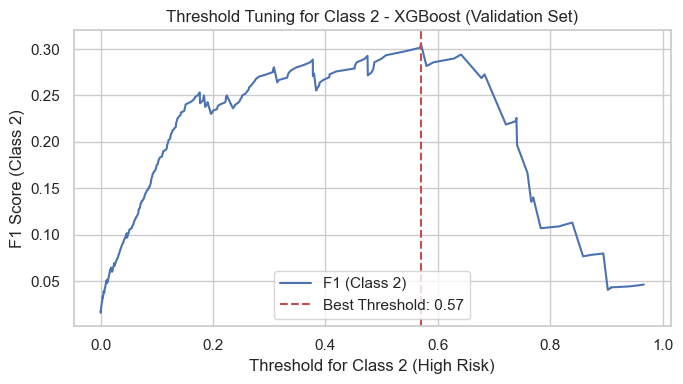


Threshold for recall >= 0.20 (validation): 0.00
F1: 0.0161, Precision: 0.0081, Recall: 1.0000

Classification report (default multiclass argmax, val):
              precision    recall  f1-score   support

           0     0.9026    0.9628    0.9317      4565
           1     0.4353    0.1979    0.2721       561
           2     0.2727    0.2857    0.2791        42

    accuracy                         0.8742      5168
   macro avg     0.5369    0.4821    0.4943      5168
weighted avg     0.8468    0.8742    0.8548      5168


Classification report (with threshold tuning for best F1, threshold=0.57):
              precision    recall  f1-score   support

           0     0.9026    0.9628    0.9317      4565
           1     0.4353    0.1979    0.2721       561
           2     0.2727    0.2857    0.2791        42

    accuracy                         0.8742      5168
   macro avg     0.5369    0.4821    0.4943      5168
weighted avg     0.8468    0.8742    0.8548      5168


Classific

In [33]:
# === Select model for threshold tuning ===
model_name = "XGBoost" 

# === Load validation set predictions ===
y_prob_val = results[model_name]["y_prob"]    
y_val_bin_class2 = (y_val == 2).astype(int)   
y_prob_class2_val = y_prob_val[:, 2]          

# === Calculate precision, recall, and F1 for all thresholds ===
precisions, recalls, thresholds = precision_recall_curve(y_val_bin_class2, y_prob_class2_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# === Find best threshold for max F1 (class 2) ===
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for class 2 (High Risk, validation): {best_threshold:.3f}")
print(f"Best F1 (class 2, val): {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

# === Plot F1 vs Threshold ===
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores[:-1], label="F1 (Class 2)")
plt.xlabel("Threshold for Class 2 (High Risk)")
plt.ylabel("F1 Score (Class 2)")
plt.title(f"Threshold Tuning for Class 2 - {model_name} (Validation Set)")
plt.axvline(best_threshold, color="r", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Predict: default (argmax), best F1, target recall (ex: 0.3 or 0.2) ===
y_pred_default_val = np.argmax(y_prob_val, axis=1)

# Apply threshold tuning: best F1
y_pred_thresh_best = y_pred_default_val.copy()
mask_highrisk_best = (y_prob_class2_val > best_threshold)
y_pred_thresh_best[mask_highrisk_best] = 2

# === Threshold for a specific recall ===
target_recall = 0.2 # 0.3 or 0.2 for class 2 – High Risk is good and realistic
possible = np.where(recalls >= target_recall)[0]
if possible.size > 0:
    idx = possible[0]
    target_threshold = thresholds[idx]
    print(f"\nThreshold for recall >= {target_recall:.2f} (validation): {target_threshold:.2f}")
    print(f"F1: {f1_scores[idx]:.4f}, Precision: {precisions[idx]:.4f}, Recall: {recalls[idx]:.4f}")
    # Apply this threshold as well
    y_pred_thresh_target = y_pred_default_val.copy()
    mask_highrisk_target = (y_prob_class2_val > target_threshold)
    y_pred_thresh_target[mask_highrisk_target] = 2
else:
    print(f"\nNo threshold achieves recall >= {target_recall:.2f} on class 2 (validation).")
    y_pred_thresh_target = None

# === Classification reports: ===
print("\nClassification report (default multiclass argmax, val):")
print(classification_report(y_val, y_pred_default_val, digits=4))

print(f"\nClassification report (with threshold tuning for best F1, threshold={best_threshold:.2f}):")
print(classification_report(y_val, y_pred_thresh_best, digits=4))

if y_pred_thresh_target is not None:
    print(f"\nClassification report (with threshold tuning for recall >= {target_recall:.2f}, threshold={target_threshold:.2f}):")
    print(classification_report(y_val, y_pred_thresh_target, digits=4))


Best threshold for class 2 (High Risk, validation): 0.280
Best F1 (class 2, val): 0.4091
Precision: 0.3913, Recall: 0.4286


<Figure size 700x400 with 0 Axes>

Text(0.5, 0, 'Threshold for Class 2 (High Risk)')

Text(0, 0.5, 'F1 Score (Class 2)')

Text(0.5, 1.0, 'Threshold (0.3) Tuning for Class 2 - Random Forest (Validation Set)')

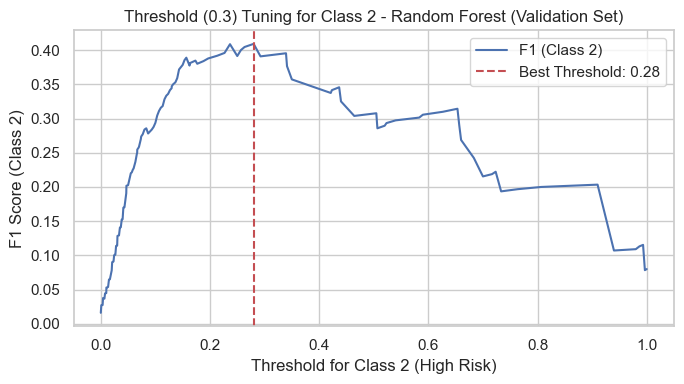


Threshold for recall >= 0.30 (validation): 0.00
F1: 0.0161, Precision: 0.0081, Recall: 1.0000

Classification report (default multiclass argmax, val):
              precision    recall  f1-score   support

           0     0.9193    0.9363    0.9277      4565
           1     0.4286    0.3690    0.3966       561
           2     0.3333    0.2857    0.3077        42

    accuracy                         0.8694      5168
   macro avg     0.5604    0.5303    0.5440      5168
weighted avg     0.8613    0.8694    0.8650      5168


Classification report (with threshold tuning for best F1, threshold=0.28):
              precision    recall  f1-score   support

           0     0.9201    0.9356    0.9278      4565
           1     0.4304    0.3690    0.3973       561
           2     0.3778    0.4048    0.3908        42

    accuracy                         0.8698      5168
   macro avg     0.5761    0.5698    0.5720      5168
weighted avg     0.8625    0.8698    0.8658      5168


Classific

In [34]:
# === Select model for threshold tuning ===
model_name = "Random Forest" 

# === Load validation set predictions ===
y_prob_val = results[model_name]["y_prob"]    
y_val_bin_class2 = (y_val == 2).astype(int)   
y_prob_class2_val = y_prob_val[:, 2]          

# === Calculate precision, recall, and F1 for all thresholds ===
precisions, recalls, thresholds = precision_recall_curve(y_val_bin_class2, y_prob_class2_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# === Find best threshold for max F1 (class 2) ===
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for class 2 (High Risk, validation): {best_threshold:.3f}")
print(f"Best F1 (class 2, val): {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

# === Plot F1 vs Threshold ===
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores[:-1], label="F1 (Class 2)")
plt.xlabel("Threshold for Class 2 (High Risk)")
plt.ylabel("F1 Score (Class 2)")
plt.title(f"Threshold (0.3) Tuning for Class 2 - {model_name} (Validation Set)")
plt.axvline(best_threshold, color="r", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Predict: default (argmax), best F1, target recall (ex: 0.3 or 0.2) ===
y_pred_default_val = np.argmax(y_prob_val, axis=1)

# Apply threshold tuning: best F1
y_pred_thresh_best = y_pred_default_val.copy()
mask_highrisk_best = (y_prob_class2_val > best_threshold)
y_pred_thresh_best[mask_highrisk_best] = 2

# === Threshold for a specific recall ===
target_recall = 0.3 # 0.3 or 0.2 for class 2 – High Risk is good and realistic
possible = np.where(recalls >= target_recall)[0]
if possible.size > 0:
    idx = possible[0]
    target_threshold = thresholds[idx]
    print(f"\nThreshold for recall >= {target_recall:.2f} (validation): {target_threshold:.2f}")
    print(f"F1: {f1_scores[idx]:.4f}, Precision: {precisions[idx]:.4f}, Recall: {recalls[idx]:.4f}")
    # Apply this threshold as well
    y_pred_thresh_target = y_pred_default_val.copy()
    mask_highrisk_target = (y_prob_class2_val > target_threshold)
    y_pred_thresh_target[mask_highrisk_target] = 2
else:
    print(f"\nNo threshold achieves recall >= {target_recall:.2f} on class 2 (validation).")
    y_pred_thresh_target = None

# === Classification reports: ===
print("\nClassification report (default multiclass argmax, val):")
print(classification_report(y_val, y_pred_default_val, digits=4))

print(f"\nClassification report (with threshold tuning for best F1, threshold={best_threshold:.2f}):")
print(classification_report(y_val, y_pred_thresh_best, digits=4))

if y_pred_thresh_target is not None:
    print(f"\nClassification report (with threshold tuning for recall >= {target_recall:.2f}, threshold={target_threshold:.2f}):")
    print(classification_report(y_val, y_pred_thresh_target, digits=4))


Best threshold for class 2 (High Risk, validation): 0.280
Best F1 (class 2, val): 0.4091
Precision: 0.3913, Recall: 0.4286


<Figure size 700x400 with 0 Axes>

Text(0.5, 0, 'Threshold for Class 2 (High Risk)')

Text(0, 0.5, 'F1 Score (Class 2)')

Text(0.5, 1.0, 'Threshold (0.2) Tuning for Class 2 - Random Forest (Validation Set)')

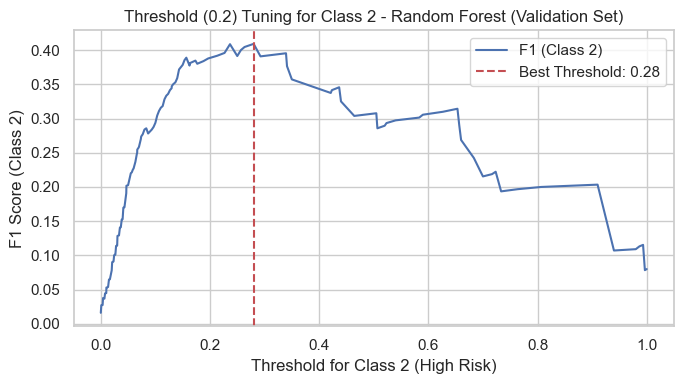


Threshold for recall >= 0.20 (validation): 0.00
F1: 0.0161, Precision: 0.0081, Recall: 1.0000

Classification report (default multiclass argmax, val):
              precision    recall  f1-score   support

           0     0.9193    0.9363    0.9277      4565
           1     0.4286    0.3690    0.3966       561
           2     0.3333    0.2857    0.3077        42

    accuracy                         0.8694      5168
   macro avg     0.5604    0.5303    0.5440      5168
weighted avg     0.8613    0.8694    0.8650      5168


Classification report (with threshold tuning for best F1, threshold=0.28):
              precision    recall  f1-score   support

           0     0.9201    0.9356    0.9278      4565
           1     0.4304    0.3690    0.3973       561
           2     0.3778    0.4048    0.3908        42

    accuracy                         0.8698      5168
   macro avg     0.5761    0.5698    0.5720      5168
weighted avg     0.8625    0.8698    0.8658      5168


Classific

In [35]:
# === Select model for threshold tuning ===
model_name = "Random Forest" 

# === Load validation set predictions ===
y_prob_val = results[model_name]["y_prob"]    
y_val_bin_class2 = (y_val == 2).astype(int)   
y_prob_class2_val = y_prob_val[:, 2]          

# === Calculate precision, recall, and F1 for all thresholds ===
precisions, recalls, thresholds = precision_recall_curve(y_val_bin_class2, y_prob_class2_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# === Find best threshold for max F1 (class 2) ===
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for class 2 (High Risk, validation): {best_threshold:.3f}")
print(f"Best F1 (class 2, val): {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

# === Plot F1 vs Threshold ===
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores[:-1], label="F1 (Class 2)")
plt.xlabel("Threshold for Class 2 (High Risk)")
plt.ylabel("F1 Score (Class 2)")
plt.title(f"Threshold (0.2) Tuning for Class 2 - {model_name} (Validation Set)")
plt.axvline(best_threshold, color="r", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Predict: default (argmax), best F1, target recall (ex: 0.3 or 0.2) ===
y_pred_default_val = np.argmax(y_prob_val, axis=1)

# Apply threshold tuning: best F1
y_pred_thresh_best = y_pred_default_val.copy()
mask_highrisk_best = (y_prob_class2_val > best_threshold)
y_pred_thresh_best[mask_highrisk_best] = 2

# === Threshold for a specific recall ===
target_recall = 0.2 # 0.3 or 0.2 for class 2 – High Risk is good and realistic
possible = np.where(recalls >= target_recall)[0]
if possible.size > 0:
    idx = possible[0]
    target_threshold = thresholds[idx]
    print(f"\nThreshold for recall >= {target_recall:.2f} (validation): {target_threshold:.2f}")
    print(f"F1: {f1_scores[idx]:.4f}, Precision: {precisions[idx]:.4f}, Recall: {recalls[idx]:.4f}")
    # Apply this threshold as well
    y_pred_thresh_target = y_pred_default_val.copy()
    mask_highrisk_target = (y_prob_class2_val > target_threshold)
    y_pred_thresh_target[mask_highrisk_target] = 2
else:
    print(f"\nNo threshold achieves recall >= {target_recall:.2f} on class 2 (validation).")
    y_pred_thresh_target = None

# === Classification reports: ===
print("\nClassification report (default multiclass argmax, val):")
print(classification_report(y_val, y_pred_default_val, digits=4))

print(f"\nClassification report (with threshold tuning for best F1, threshold={best_threshold:.2f}):")
print(classification_report(y_val, y_pred_thresh_best, digits=4))

if y_pred_thresh_target is not None:
    print(f"\nClassification report (with threshold tuning for recall >= {target_recall:.2f}, threshold={target_threshold:.2f}):")
    print(classification_report(y_val, y_pred_thresh_target, digits=4))


Best threshold for class 2 (High Risk, validation): 0.450
Best F1 (class 2, val): 0.2785
Precision: 0.2973, Recall: 0.2619


<Figure size 700x400 with 0 Axes>

Text(0.5, 0, 'Threshold for Class 2 (High Risk)')

Text(0, 0.5, 'F1 Score (Class 2)')

Text(0.5, 1.0, 'Threshold (0.3) Tuning for Class 2 - LightGBM (Validation Set)')

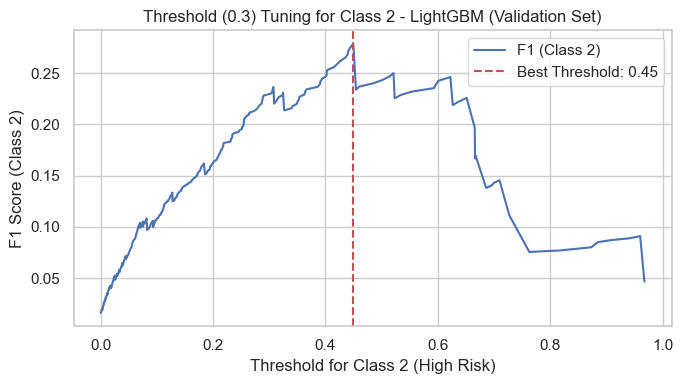


Threshold for recall >= 0.30 (validation): 0.00
F1: 0.0161, Precision: 0.0081, Recall: 1.0000

Classification report (default multiclass argmax, val):
              precision    recall  f1-score   support

           0     0.8965    0.9768    0.9349      4565
           1     0.4771    0.1301    0.2045       561
           2     0.2683    0.2619    0.2651        42

    accuracy                         0.8791      5168
   macro avg     0.5473    0.4563    0.4681      5168
weighted avg     0.8458    0.8791    0.8502      5168


Classification report (with threshold tuning for best F1, threshold=0.45):
              precision    recall  f1-score   support

           0     0.8964    0.9766    0.9348      4565
           1     0.4771    0.1301    0.2045       561
           2     0.2619    0.2619    0.2619        42

    accuracy                         0.8789      5168
   macro avg     0.5452    0.4562    0.4671      5168
weighted avg     0.8458    0.8789    0.8500      5168


Classific

In [36]:
# === Select model for threshold tuning ===
model_name = "LightGBM" 

# === Load validation set predictions ===
y_prob_val = results[model_name]["y_prob"]    
y_val_bin_class2 = (y_val == 2).astype(int)   
y_prob_class2_val = y_prob_val[:, 2]          

# === Calculate precision, recall, and F1 for all thresholds ===
precisions, recalls, thresholds = precision_recall_curve(y_val_bin_class2, y_prob_class2_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# === Find best threshold for max F1 (class 2) ===
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for class 2 (High Risk, validation): {best_threshold:.3f}")
print(f"Best F1 (class 2, val): {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

# === Plot F1 vs Threshold ===
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores[:-1], label="F1 (Class 2)")
plt.xlabel("Threshold for Class 2 (High Risk)")
plt.ylabel("F1 Score (Class 2)")
plt.title(f"Threshold (0.3) Tuning for Class 2 - {model_name} (Validation Set)")
plt.axvline(best_threshold, color="r", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Predict: default (argmax), best F1, target recall (ex: 0.3 or 0.2) ===
y_pred_default_val = np.argmax(y_prob_val, axis=1)

# Apply threshold tuning: best F1
y_pred_thresh_best = y_pred_default_val.copy()
mask_highrisk_best = (y_prob_class2_val > best_threshold)
y_pred_thresh_best[mask_highrisk_best] = 2

# === Threshold for a specific recall ===
target_recall = 0.3 # 0.3 or 0.2 for class 2 – High Risk is good and realistic
possible = np.where(recalls >= target_recall)[0]
if possible.size > 0:
    idx = possible[0]
    target_threshold = thresholds[idx]
    print(f"\nThreshold for recall >= {target_recall:.2f} (validation): {target_threshold:.2f}")
    print(f"F1: {f1_scores[idx]:.4f}, Precision: {precisions[idx]:.4f}, Recall: {recalls[idx]:.4f}")
    # Apply this threshold as well
    y_pred_thresh_target = y_pred_default_val.copy()
    mask_highrisk_target = (y_prob_class2_val > target_threshold)
    y_pred_thresh_target[mask_highrisk_target] = 2
else:
    print(f"\nNo threshold achieves recall >= {target_recall:.2f} on class 2 (validation).")
    y_pred_thresh_target = None

# === Classification reports: ===
print("\nClassification report (default multiclass argmax, val):")
print(classification_report(y_val, y_pred_default_val, digits=4))

print(f"\nClassification report (with threshold tuning for best F1, threshold={best_threshold:.2f}):")
print(classification_report(y_val, y_pred_thresh_best, digits=4))

if y_pred_thresh_target is not None:
    print(f"\nClassification report (with threshold tuning for recall >= {target_recall:.2f}, threshold={target_threshold:.2f}):")
    print(classification_report(y_val, y_pred_thresh_target, digits=4))


Best threshold for class 2 (High Risk, validation): 0.450
Best F1 (class 2, val): 0.2785
Precision: 0.2973, Recall: 0.2619


<Figure size 700x400 with 0 Axes>

Text(0.5, 0, 'Threshold for Class 2 (High Risk)')

Text(0, 0.5, 'F1 Score (Class 2)')

Text(0.5, 1.0, 'Threshold (0.2) Tuning for Class 2 - LightGBM (Validation Set)')

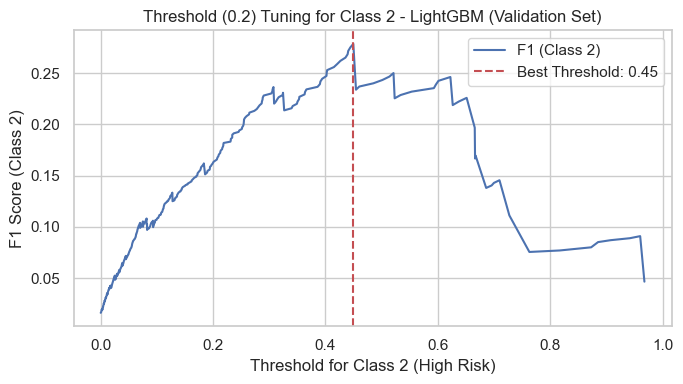


Threshold for recall >= 0.20 (validation): 0.00
F1: 0.0161, Precision: 0.0081, Recall: 1.0000

Classification report (default multiclass argmax, val):
              precision    recall  f1-score   support

           0     0.8965    0.9768    0.9349      4565
           1     0.4771    0.1301    0.2045       561
           2     0.2683    0.2619    0.2651        42

    accuracy                         0.8791      5168
   macro avg     0.5473    0.4563    0.4681      5168
weighted avg     0.8458    0.8791    0.8502      5168


Classification report (with threshold tuning for best F1, threshold=0.45):
              precision    recall  f1-score   support

           0     0.8964    0.9766    0.9348      4565
           1     0.4771    0.1301    0.2045       561
           2     0.2619    0.2619    0.2619        42

    accuracy                         0.8789      5168
   macro avg     0.5452    0.4562    0.4671      5168
weighted avg     0.8458    0.8789    0.8500      5168


Classific

In [37]:
# === Select model for threshold tuning ===
model_name = "LightGBM" 

# === Load validation set predictions ===
y_prob_val = results[model_name]["y_prob"]    
y_val_bin_class2 = (y_val == 2).astype(int)   
y_prob_class2_val = y_prob_val[:, 2]          

# === Calculate precision, recall, and F1 for all thresholds ===
precisions, recalls, thresholds = precision_recall_curve(y_val_bin_class2, y_prob_class2_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# === Find best threshold for max F1 (class 2) ===
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for class 2 (High Risk, validation): {best_threshold:.3f}")
print(f"Best F1 (class 2, val): {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

# === Plot F1 vs Threshold ===
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores[:-1], label="F1 (Class 2)")
plt.xlabel("Threshold for Class 2 (High Risk)")
plt.ylabel("F1 Score (Class 2)")
plt.title(f"Threshold (0.2) Tuning for Class 2 - {model_name} (Validation Set)")
plt.axvline(best_threshold, color="r", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Predict: default (argmax), best F1, target recall (ex: 0.3 or 0.2) ===
y_pred_default_val = np.argmax(y_prob_val, axis=1)

# Apply threshold tuning: best F1
y_pred_thresh_best = y_pred_default_val.copy()
mask_highrisk_best = (y_prob_class2_val > best_threshold)
y_pred_thresh_best[mask_highrisk_best] = 2

# === Threshold for a specific recall ===
target_recall = 0.2 # 0.3 or 0.2 for class 2 – High Risk is good and realistic
possible = np.where(recalls >= target_recall)[0]
if possible.size > 0:
    idx = possible[0]
    target_threshold = thresholds[idx]
    print(f"\nThreshold for recall >= {target_recall:.2f} (validation): {target_threshold:.2f}")
    print(f"F1: {f1_scores[idx]:.4f}, Precision: {precisions[idx]:.4f}, Recall: {recalls[idx]:.4f}")
    # Apply this threshold as well
    y_pred_thresh_target = y_pred_default_val.copy()
    mask_highrisk_target = (y_prob_class2_val > target_threshold)
    y_pred_thresh_target[mask_highrisk_target] = 2
else:
    print(f"\nNo threshold achieves recall >= {target_recall:.2f} on class 2 (validation).")
    y_pred_thresh_target = None

# === Classification reports: ===
print("\nClassification report (default multiclass argmax, val):")
print(classification_report(y_val, y_pred_default_val, digits=4))

print(f"\nClassification report (with threshold tuning for best F1, threshold={best_threshold:.2f}):")
print(classification_report(y_val, y_pred_thresh_best, digits=4))

if y_pred_thresh_target is not None:
    print(f"\nClassification report (with threshold tuning for recall >= {target_recall:.2f}, threshold={target_threshold:.2f}):")
    print(classification_report(y_val, y_pred_thresh_target, digits=4))

In [38]:

model_names = [
    "Random Forest",
    "XGBoost",
    "LightGBM",
]

results_summary = []

for model_name in model_names:
    print(f"--- {model_name} ---")
    # Load validation predictions
    y_prob_val = results[model_name]["y_prob"]
    y_true_val = y_val

    y_prob_class2_val = y_prob_val[:, 2]
    y_true_class2_val = (y_true_val == 2).astype(int)

    # Precision, recall, F1 by threshold
    precisions, recalls, thresholds = precision_recall_curve(y_true_class2_val, y_prob_class2_val)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

    # Best threshold for F1 (class 2)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_prec = precisions[best_idx]
    best_rec = recalls[best_idx]

    # Generate predictions at best threshold
    y_pred_best = np.argmax(y_prob_val, axis=1)
    mask_highrisk = (y_prob_class2_val > best_threshold)
    y_pred_best[mask_highrisk] = 2

    # Compute macro F1
    macro_f1 = f1_score(y_true_val, y_pred_best, average='macro')

    # Save results
    results_summary.append({
        "Model": model_name,
        "Best Threshold": round(best_threshold, 3),
        "F1 Score (Class 2)": round(best_f1, 4),
        "Precision (Class 2)": round(best_prec, 4),
        "Recall (Class 2)": round(best_rec, 4),
        "F1 Macro": round(macro_f1, 4)
    })

    print(f"Best Threshold: {best_threshold:.3f}")
    print(f"F1 Score (Class 2): {best_f1:.4f}")
    print(f"Precision: {best_prec:.4f}, Recall: {best_rec:.4f}")
    print(f"F1 Macro: {macro_f1:.4f}\n")

# Display as a Pandas DataFrame
df_summary = pd.DataFrame(results_summary)
print(df_summary)

# Save table to CSV
df_summary.to_csv("threshold_tuning_class2_summary_validation_with_macro.csv", index=False)


--- Random Forest ---
Best Threshold: 0.280
F1 Score (Class 2): 0.4091
Precision: 0.3913, Recall: 0.4286
F1 Macro: 0.5720

--- XGBoost ---
Best Threshold: 0.570
F1 Score (Class 2): 0.3056
Precision: 0.3667, Recall: 0.2619
F1 Macro: 0.4943

--- LightGBM ---
Best Threshold: 0.450
F1 Score (Class 2): 0.2785
Precision: 0.2973, Recall: 0.2619
F1 Macro: 0.4671

           Model  Best Threshold  F1 Score (Class 2)  Precision (Class 2)  \
0  Random Forest            0.28              0.4091               0.3913   
1        XGBoost            0.57              0.3056               0.3667   
2       LightGBM            0.45              0.2785               0.2973   

   Recall (Class 2)  F1 Macro  
0            0.4286    0.5720  
1            0.2619    0.4943  
2            0.2619    0.4671  


CatBoost class_weights: [0.37738033766762114, 3.0661072972285788, 41.6545768566494]

=== Final Testing: Logistic Regression ===


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 LogisticRegression(C=100, class_weight='balanced',
                                    max_iter=10000, random_state=42,
                                    solver='liblinear'))])

              precision    recall  f1-score   support

           0     0.8849    0.9901    0.9346      4566
           1     0.2857    0.0036    0.0070       562
           2     0.1132    0.1463    0.1277        41

    accuracy                         0.8762      5169
   macro avg     0.4279    0.3800    0.3564      5169
weighted avg     0.8136    0.8762    0.8273      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression (Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

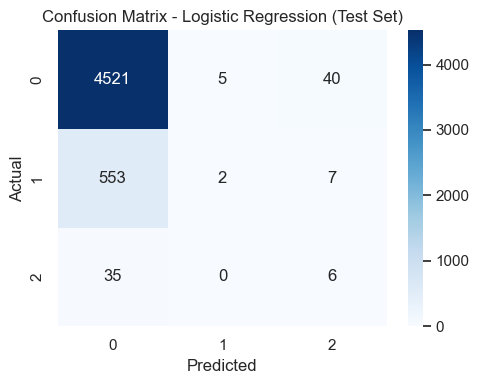


=== Final Testing: Random Forest ===


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=25,
                                        min_samples_leaf=2, n_jobs=-1,
                                        random_state=42))])

              precision    recall  f1-score   support

           0     0.9156    0.9385    0.9269      4566
           1     0.4026    0.3274    0.3611       562
           2     0.4062    0.3171    0.3562        41

    accuracy                         0.8671      5169
   macro avg     0.5748    0.5276    0.5481      5169
weighted avg     0.8558    0.8671    0.8608      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

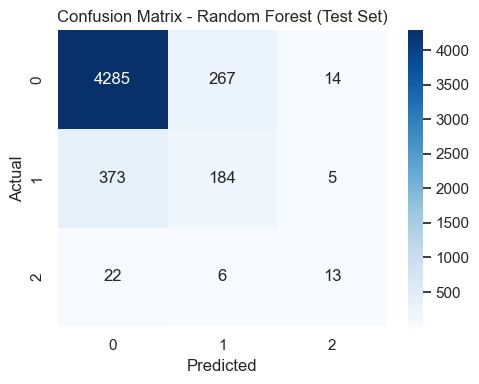


Classification report (with threshold tuning for best F1, threshold=0.28):
              precision    recall  f1-score   support

           0     0.9164    0.9358    0.9260      4566
           1     0.4013    0.3221    0.3574       562
           2     0.3091    0.4146    0.3542        41

    accuracy                         0.8650      5169
   macro avg     0.5423    0.5575    0.5458      5169
weighted avg     0.8555    0.8650    0.8596      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Threshold Tuned, Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

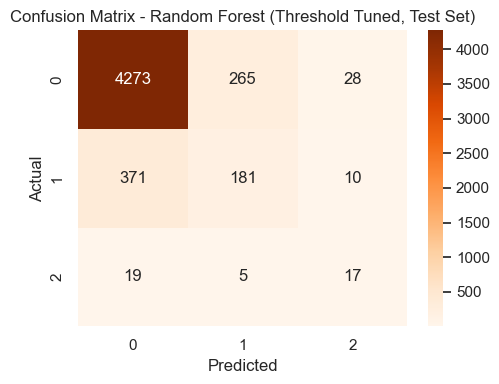


=== Final Testing: Gradient Boosting ===


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 GradientBoostingClassifier(learning_rate=0.3, max_depth=5,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

              precision    recall  f1-score   support

           0     0.8984    0.9391    0.9183      4566
           1     0.3705    0.1655    0.2288       562
           2     0.0483    0.1707    0.0753        41

    accuracy                         0.8489      5169
   macro avg     0.4391    0.4251    0.4075      5169
weighted avg     0.8343    0.8489    0.8366      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Gradient Boosting (Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

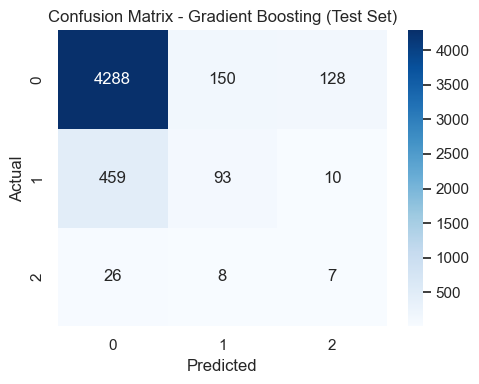


=== Final Testing: XGBoost ===


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.6,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=None,
                               num_parallel_tree=None, ...))])

              precision    recall  f1-score   support

           0     0.9087    0.9485    0.9282      4566
           1     0.3922    0.2687    0.3189       562
           2     0.4444    0.1951    0.2712        41

    accuracy                         0.8686      5169
   macro avg     0.5818    0.4708    0.5061      5169
weighted avg     0.8489    0.8686    0.8567      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - XGBoost (Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

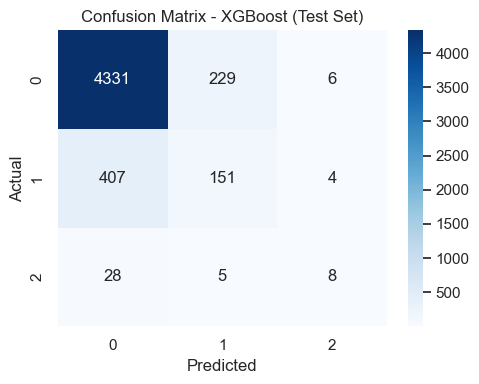


=== Final Testing: LightGBM ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3941
[LightGBM] [Info] Number of data points in the train set: 24118, number of used features: 68
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.2,
                                max_depth=9, n_estimators=300, random_state=42,
                                subsample=0.8))])

              precision    recall  f1-score   support

           0     0.9256    0.8887    0.9068      4566
           1     0.3290    0.4466    0.3789       562
           2     0.3636    0.1951    0.2540        41

    accuracy                         0.8352      5169
   macro avg     0.5394    0.5102    0.5132      5169
weighted avg     0.8563    0.8352    0.8442      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - LightGBM (Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

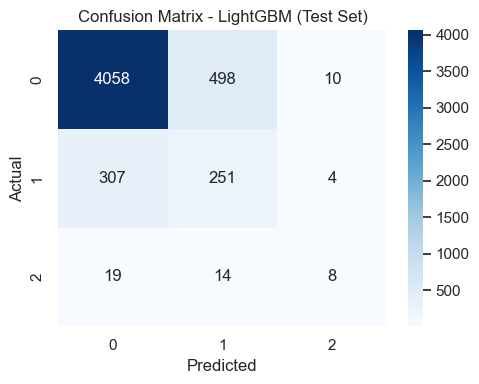


=== Final Testing: CatBoost ===


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 <catboost.core.CatBoostClassifier object at 0x000001CE27246870>)])

              precision    recall  f1-score   support

           0     0.9207    0.8778    0.8988      4566
           1     0.2953    0.4057    0.3418       562
           2     0.2500    0.2683    0.2588        41

    accuracy                         0.8216      5169
   macro avg     0.4887    0.5173    0.4998      5169
weighted avg     0.8474    0.8216    0.8331      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - CatBoost (Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

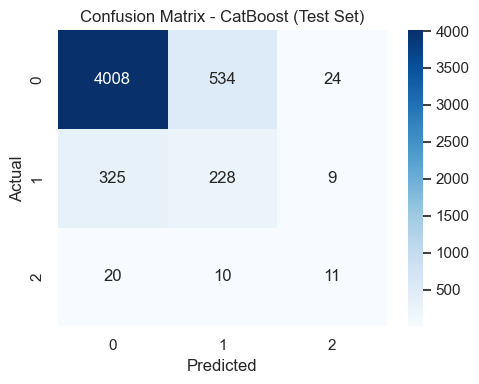


=== Final Testing: AdaBoost ===


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                                    n_estimators=150, random_state=42))])

              precision    recall  f1-score   support

           0     0.8833    0.9993    0.9377      4566
           1     0.0000    0.0000    0.0000       562
           2     0.0000    0.0000    0.0000        41

    accuracy                         0.8828      5169
   macro avg     0.2944    0.3331    0.3126      5169
weighted avg     0.7802    0.8828    0.8283      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - AdaBoost (Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

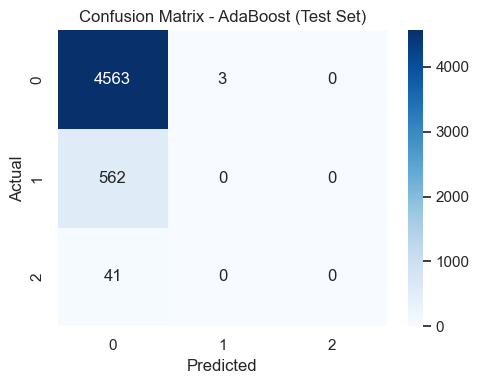


=== Final Testing: Balanced Random Forest ===


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 BalancedRandomForestClassifier(max_depth=20,
                                                min_samples_split=3,
                                                n_estimators=150, n_jobs=-1,
                                                random_state=42))])

              precision    recall  f1-score   support

           0     0.9241    0.5600    0.6974      4566
           1     0.1575    0.5409    0.2440       562
           2     0.0508    0.5854    0.0936        41

    accuracy                         0.5581      5169
   macro avg     0.3775    0.5621    0.3450      5169
weighted avg     0.8338    0.5581    0.6433      5169



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Balanced Random Forest (Test Set)')

Text(0.5, 11.249999999999995, 'Predicted')

Text(29.75, 0.5, 'Actual')

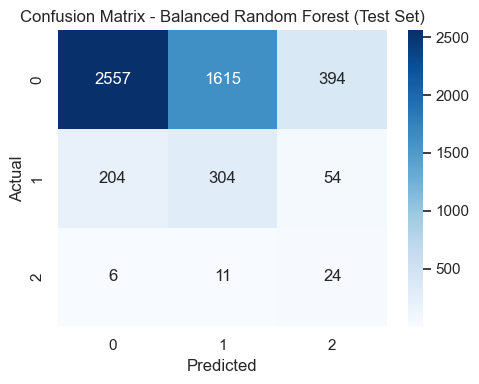


=== Final Model Comparison (Test Set) ===
                       Model  F1 Macro  AUC-ROC  AP Macro  Recall (Class 2)  \
0        Logistic Regression    0.3564   0.6103    0.3757            0.1463   
1  Random Forest (Threshold)    0.5458   0.7584    0.5208            0.4146   
2              Random Forest    0.5481   0.7584    0.5208            0.3171   
3          Gradient Boosting    0.4075   0.7260    0.4079            0.1707   
4                    XGBoost    0.5061   0.7624    0.4838            0.1951   
5                   LightGBM    0.5132   0.7658    0.5013            0.1951   
6                   CatBoost    0.4998   0.7519    0.4788            0.2683   
7                   AdaBoost    0.3126   0.6022    0.3659            0.0000   
8     Balanced Random Forest    0.3450   0.6768    0.4470            0.5854   

   Precision (Class 2)  
0               0.1132  
1               0.3091  
2               0.4062  
3               0.0483  
4               0.4444  
5               

In [39]:
# --- Calculate CatBoost class weights based on y_train ---
class_counts = y_train.value_counts().sort_index()
total = len(y_train)
catboost_weights = [total / (3 * class_counts[i]) for i in [0, 1, 2]]
print("CatBoost class_weights:", catboost_weights)


models = {
    "Logistic Regression": LogisticRegression(
        solver='liblinear', penalty='l2', C=100, class_weight='balanced', max_iter=10000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=25, min_samples_split=2, min_samples_leaf=2,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.3, max_depth=5, subsample=0.8, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.6, max_depth=7, subsample=0.4,
        colsample_bytree=0.8, scale_pos_weight=1, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    "LightGBM": LGBMClassifier(
        subsample=0.8, num_leaves=31, n_estimators=300, max_depth=9,
        learning_rate=0.2, class_weight='balanced', random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        learning_rate=0.3, iterations=300, depth=9, class_weights=catboost_weights, 
        verbose=0, random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        learning_rate=1.0,
        n_estimators=150,
        random_state=42
    ),
    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=1,
        min_samples_split=3,
        random_state=42,
        n_jobs=-1
    ),
}

# ========== Final test evaluation (no SMOTE) ==========

results_summary = []

for name, model in models.items():
    print(f"\n=== Final Testing: {name} ===")

    # Build pipeline: median imputer, no SMOTE, then model
    pipe = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', model)
    ])

    # Fit on entire training set (no resampling)
    pipe.fit(X_train_final, y_train)

    # Predict on test set
    y_pred = pipe.predict(X_test_final)
    y_prob = pipe.predict_proba(X_test_final)

    # Metrics
    f1_macro = f1_score(y_test, y_pred, average='macro')
    auc_roc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    ap_macro = average_precision_score(y_test, y_prob, average='macro')
    recall_class2 = recall_score(y_test, y_pred, labels=[2], average=None)[0]
    precision_class2 = precision_score(y_test, y_pred, labels=[2], average=None)[0]

    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name} (Test Set)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Threshold tuning for Random Forest only
    if name == "Random Forest":
        threshold = 0.28
        y_pred_thresh = y_pred.copy()
        mask_highrisk = (y_prob[:, 2] > threshold)
        y_pred_thresh[mask_highrisk] = 2

        print(f"\nClassification report (with threshold tuning for best F1, threshold={threshold:.2f}):")
        print(classification_report(y_test, y_pred_thresh, digits=4))
        cm_thresh = confusion_matrix(y_test, y_pred_thresh)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm_thresh, annot=True, fmt='d', cmap='Oranges')
        plt.title("Confusion Matrix - Random Forest (Threshold Tuned, Test Set)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

        # Metrics for threshold-tuned RF
        f1_macro_thresh = f1_score(y_test, y_pred_thresh, average='macro')
        auc_roc_thresh = roc_auc_score(y_test, y_prob, multi_class='ovr')
        ap_macro_thresh = average_precision_score(y_test, y_prob, average='macro')
        recall_class2_thresh = recall_score(y_test, y_pred_thresh, labels=[2], average=None)[0]
        precision_class2_thresh = precision_score(y_test, y_pred_thresh, labels=[2], average=None)[0]

        results_summary.append({
            "Model": "Random Forest (Threshold)",
            "F1 Macro": round(f1_macro_thresh, 4),
            "AUC-ROC": round(auc_roc_thresh, 4),
            "AP Macro": round(ap_macro_thresh, 4),
            "Recall (Class 2)": round(recall_class2_thresh, 4),
            "Precision (Class 2)": round(precision_class2_thresh, 4)
        })

    # Save default results for each model
    results_summary.append({
        "Model": name,
        "F1 Macro": round(f1_macro, 4),
        "AUC-ROC": round(auc_roc, 4),
        "AP Macro": round(ap_macro, 4),
        "Recall (Class 2)": round(recall_class2, 4),
        "Precision (Class 2)": round(precision_class2, 4)
    })

# === Display and save results as DataFrame ===
df_results = pd.DataFrame(results_summary)
print("\n=== Final Model Comparison (Test Set) ===")
print(df_results)

df_results.to_csv("final_model_comparison_testset.csv", index=False)


In [40]:

# Define and train the final Random Forest pipeline with best hyperparameters
rf_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=25,
        min_samples_split=2,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train_final, y_train)

# Set the best threshold found for class 2
best_threshold = 0.28   # <- use the threshold identified in your tuning


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=25,
                                        min_samples_leaf=2, n_jobs=-1,
                                        random_state=42))])

In [42]:

# Save the trained pipeline
joblib.dump(rf_pipeline, "best_rf_pipeline.pkl")

# Save the threshold for class 2 (High Risk)
with open("best_rf_threshold.txt", "w") as f:
    f.write(str(best_threshold))


['best_rf_pipeline.pkl']

4

In [67]:
import json

rf_hyperparams = {
    "n_estimators": 100,
    "max_depth": 25,
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "class_weight": "balanced",
    "random_state": 42,
    "imputer_strategy": "median"
}

# Save RF Hyperparameters
with open("rf_hyperparameters.json", "w") as f:
    json.dump(rf_hyperparams, f, indent=4)


In [59]:


# Asigură-te că ai toate variabilele hyperparametri deja definite!
os.makedirs("models", exist_ok=True)

# Random Forest
rf_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=100, max_depth=25, min_samples_leaf=2, min_samples_split=2,
        class_weight='balanced', random_state=42))
])
rf_pipeline.fit(X_train_final, y_train)
joblib.dump(rf_pipeline, "models/best_rf_pipeline.pkl")

# XGBoost
xgb_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(
        n_estimators=400, learning_rate=0.6, max_depth=7,
        subsample=0.4, colsample_bytree=0.8, scale_pos_weight=1,
        use_label_encoder=False, eval_metric='mlogloss', random_state=42))
])
xgb_pipeline.fit(X_train_final, y_train)
joblib.dump(xgb_pipeline, "models/best_xgb_pipeline.pkl")

# LightGBM
lgbm_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', LGBMClassifier(
        n_estimators=300, learning_rate=0.2, max_depth=9, num_leaves=31,
        subsample=0.8, class_weight='balanced', random_state=42))
])
lgbm_pipeline.fit(X_train_final, y_train)
joblib.dump(lgbm_pipeline, "models/best_lgbm_pipeline.pkl")

# CatBoost (folosește class_weights calculate de tine)
catboost_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', CatBoostClassifier(
        iterations=300, learning_rate=0.3, depth=9,
        class_weights=catboost_weights, verbose=0, random_state=42))
])
catboost_pipeline.fit(X_train_final, y_train)
joblib.dump(catboost_pipeline, "models/best_catboost_pipeline.pkl")

# Gradient Boosting
gb_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.3, max_depth=5, subsample=0.8, random_state=42))
])
gb_pipeline.fit(X_train_final, y_train)
joblib.dump(gb_pipeline, "models/best_gb_pipeline.pkl")

# Logistic Regression
lr_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', LogisticRegression(
        C=100, solver='liblinear', penalty='l2', class_weight='balanced', random_state=42, max_iter=10000))
])
lr_pipeline.fit(X_train_final, y_train)
joblib.dump(lr_pipeline, "models/best_lr_pipeline.pkl")

# AdaBoost (cu base estimator)
from sklearn.tree import DecisionTreeClassifier
ada_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        learning_rate=1.0, n_estimators=150, random_state=42))
])
ada_pipeline.fit(X_train_final, y_train)
joblib.dump(ada_pipeline, "models/best_ada_pipeline.pkl")

# Balanced Random Forest
from imblearn.ensemble import BalancedRandomForestClassifier
brf_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', BalancedRandomForestClassifier(
        n_estimators=150, max_depth=20, min_samples_leaf=1, min_samples_split=3, random_state=42))
])
brf_pipeline.fit(X_train_final, y_train)
joblib.dump(brf_pipeline, "models/best_brf_pipeline.pkl")

print("All pipelines trained and saved to 'models/' folder!")


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=25,
                                        min_samples_leaf=2, random_state=42))])

['models/best_rf_pipeline.pkl']

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.6,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=None,
                               num_parallel_tree=None, ...))])

['models/best_xgb_pipeline.pkl']

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3941
[LightGBM] [Info] Number of data points in the train set: 24118, number of used features: 68
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                                    n_estimators=150, random_state=42))])

['models/best_ada_pipeline.pkl']

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 BalancedRandomForestClassifier(max_depth=20,
                                                min_samples_split=3,
                                                n_estimators=150,
                                                random_state=42))])

['models/best_brf_pipeline.pkl']

All pipelines trained and saved to 'models/' folder!


In [68]:

all_hyperparams = {
    "RandomForest": {
        "class_weight": "balanced",
        "max_depth": 25,
        "min_samples_leaf": 2,
        "min_samples_split": 2,
        "n_estimators": 100
    },
    "BalancedRandomForest": {
        "max_depth": 20,
        "min_samples_leaf": 1,
        "min_samples_split": 3,
        "n_estimators": 150
    },
    "XGBoost": {
        "colsample_bytree": 0.8,
        "learning_rate": 0.6,
        "max_depth": 7,
        "n_estimators": 400,
        "scale_pos_weight": 1,
        "subsample": 0.4
    },
    "AdaBoost": {
        "estimator": "DecisionTreeClassifier(max_depth=3)",
        "learning_rate": 1.0,
        "n_estimators": 150
    },
    "LightGBM": {
        "subsample": 0.8,
        "num_leaves": 31,
        "n_estimators": 300,
        "max_depth": 9,
        "learning_rate": 0.2
    },
    "GradientBoosting": {
        "subsample": 0.8,
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.3
    },
    "LogisticRegression": {
        "solver": "liblinear",
        "penalty": "l2",
        "C": 100
    },
    "CatBoost": {
        "learning_rate": 0.3,
        "iterations": 300,
        "depth": 9
    }
}

with open("config.json", "w") as f:
    json.dump(all_hyperparams, f, indent=4)

print("All hyperparameters saved to config.json")


All hyperparameters saved to config.json


In [43]:
rf_pipeline = joblib.load("best_rf_pipeline.pkl")

Classification Report with Threshold Tuning:
              precision    recall  f1-score   support

           0     0.9164    0.9358    0.9260      4566
           1     0.4013    0.3221    0.3574       562
           2     0.3091    0.4146    0.3542        41

    accuracy                         0.8650      5169
   macro avg     0.5423    0.5575    0.5458      5169
weighted avg     0.8555    0.8650    0.8596      5169

F1 Macro: 0.5458384028125335
AUC-ROC: 0.7584478779038428
AP Macro: 0.5207579993040918

PR-AUC (Average Precision) for each class:
Class 0 PR-AUC: 0.9459
Class 1 PR-AUC: 0.3413
Class 2 PR-AUC: 0.2750


<Figure size 1000x800 with 0 Axes>

Text(0.5, 1.0, 'Precision-Recall Curves by Class')

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

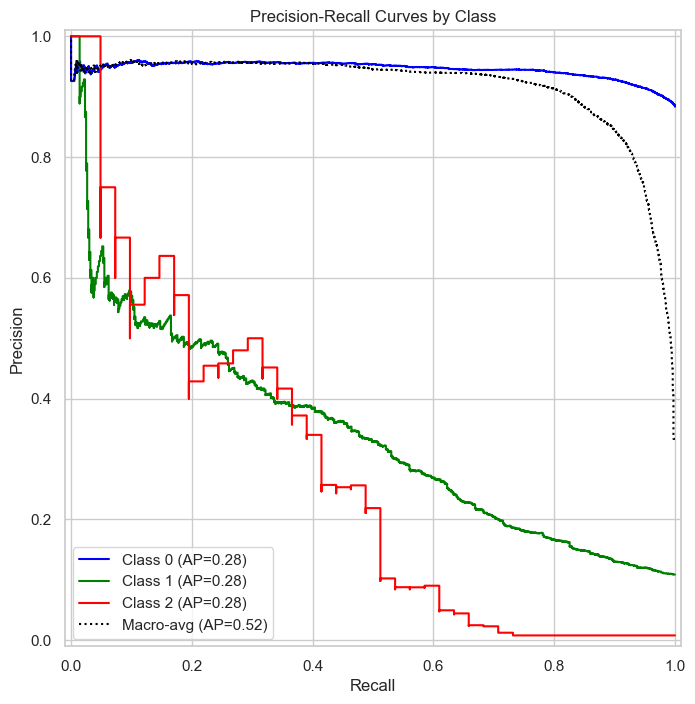

<Figure size 640x480 with 0 Axes>

In [ ]:

from sklearn.metrics import PrecisionRecallDisplay

# Load pipeline
rf_pipeline = joblib.load("best_rf_pipeline.pkl")

# Load threshold if you used threshold tuning
with open("best_rf_threshold.txt") as f:
    best_threshold = float(f.read())

# Predict proba pe test
y_prob = rf_pipeline.predict_proba(X_test_final)
y_pred_default = rf_pipeline.predict(X_test_final)

# Threshold tuning pentru clasa 2 (High Risk)
y_pred_threshold = y_pred_default.copy()
high_risk_mask = (y_prob[:, 2] > best_threshold)
y_pred_threshold[high_risk_mask] = 2

print("Classification Report with Threshold Tuning:")
print(classification_report(y_test, y_pred_threshold, digits=4))
print("F1 Macro:", f1_score(y_test, y_pred_threshold, average='macro'))
print("AUC-ROC:", roc_auc_score(y_test, y_prob, multi_class='ovr'))
print("AP Macro:", average_precision_score(y_test, y_prob, average='macro'))

# Binarize y_test for multiclass
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

print("\nPR-AUC (Average Precision) for each class:")
for i in range(y_prob.shape[1]):
    pr_auc = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    print(f"Class {i} PR-AUC: {pr_auc:.4f}")

# Create Precision-Recall curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red']
class_names = ['Class 0', 'Class 1', 'Class 2']

for i in range(y_prob.shape[1]):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    display = PrecisionRecallDisplay(recall=recall, precision=precision)
    display.plot(ax=plt.gca(), name=f'{class_names[i]} (AP={pr_auc:.2f})', color=colors[i])

# Add macro-average curve
precision_micro, recall_micro, _ = precision_recall_curve(y_test_bin.ravel(), y_prob.ravel())
pr_auc_micro = average_precision_score(y_test_bin, y_prob, average='macro')
PrecisionRecallDisplay(recall=recall_micro, precision=precision_micro).plot(
    ax=plt.gca(), name=f'Macro-avg (AP={pr_auc_micro:.2f})', color='black', linestyle=':')

plt.title('Precision-Recall Curves by Class')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Optionally save the figure
plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')

In [75]:


save_folder = "final_datasets"
os.makedirs(save_folder, exist_ok=True)


X_train_final.to_csv(f"{save_folder}/X_train_final.csv", index=False)
X_val_final.to_csv(f"{save_folder}/X_val_final.csv", index=False)
X_test_final.to_csv(f"{save_folder}/X_test_final.csv", index=False)


y_train.to_csv(f"{save_folder}/y_train.csv", index=False)
y_val.to_csv(f"{save_folder}/y_val.csv", index=False)
y_test.to_csv(f"{save_folder}/y_test.csv", index=False)

print("All datasets saved in:", save_folder)


All datasets saved in: final_datasets


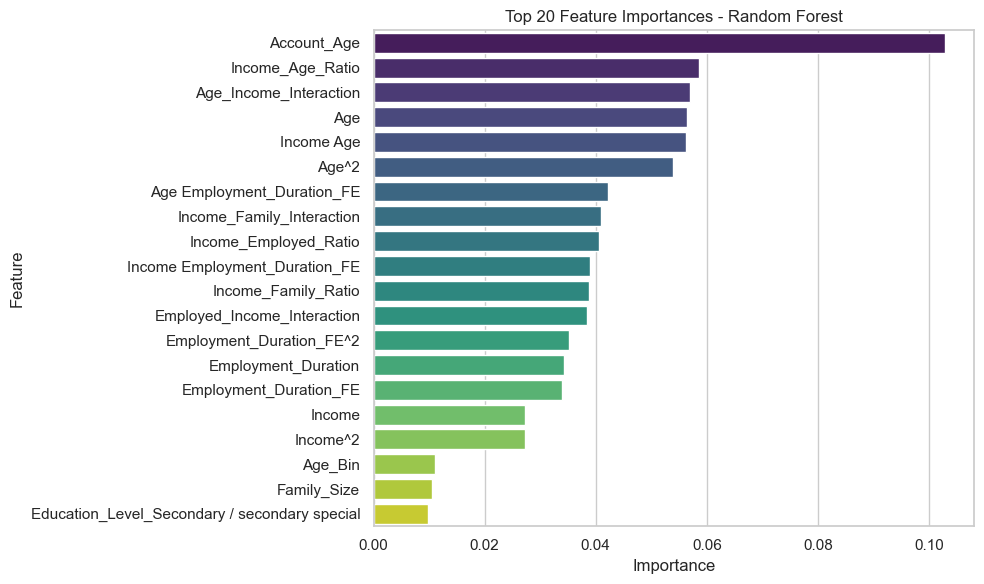

Saved plot: Top_Features_Random_Forest.png
Saved CSV: Top_Features_Random_Forest.csv


In [44]:
# === FEATURE IMPORTANCE EXTRACTION ===

# === Load trained pipeline ===
rf_pipeline = joblib.load("best_rf_pipeline.pkl")

# === Get feature names  ===
feature_names = X_train_final.columns

# === Extract and plot feature importances from pipeline ===
def plot_feature_importance(pipeline, model_name, top_n=15):
    # Extract RF classifier from pipeline
    clf = pipeline.named_steps['clf']
    importances = clf.feature_importances_
    
    # Build DataFrame with top features
    df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=df, palette='viridis')
    plt.title(f"Top {top_n} Feature Importances - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    # Save plot as PNG
    filename = f"Top_Features_{model_name.replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.show()
    print(f"Saved plot: {filename}")

    # Save top features as CSV
    csv_filename = f"Top_Features_{model_name.replace(' ', '_')}.csv"
    df.to_csv(csv_filename, index=False)
    print(f"Saved CSV: {csv_filename}")

# === Call function for your pipeline ===
plot_feature_importance(rf_pipeline, "Random Forest", top_n=20)


In [57]:

# === Select real clients for SHAP force plot ===

selected_indices = {}
for cls in [0, 1, 2]:
    mask = (df_clients_cleaned['Risk_Level'] == cls) & (df_clients_cleaned.index.isin(X_test_final_reset.index))
    indices = df_clients_cleaned[mask].index.tolist()
    if indices:
        selected_indices[cls] = indices[0]
        print(f"Selected client for class {cls}: original_idx = {indices[0]}")
        print(df_clients_cleaned.loc[indices[0]])
    else:
        print(f"No client with Risk_Level = {cls} found in the test set.")

sample_indices = {}
for cls, original_idx in selected_indices.items():
    matches = np.where(X_test_final_reset.index == original_idx)[0]
    if len(matches) > 0:
        sample_indices[cls] = matches[0]
        print(f"Class {cls}: sample_idx in X_test_final_reset = {matches[0]}")
    else:
        print(f"Client with original_idx = {original_idx} not found in processed test set.")

shap.initjs()

for cls, sample_idx in sample_indices.items():
    shap_values_instance = shap_values_rf[sample_idx, :, cls]   # shape (n_features,)
    feature_values = X_test_for_shap[sample_idx]                # shape (n_features,)
    print(f"Class {cls}: SHAP shape {shap_values_instance.shape}, Feature shape {feature_values.shape}")
    force_plot_rf = shap.force_plot(
        explainer_rf.expected_value[cls],
        shap_values_instance,
        feature_values,
        feature_names=feature_names
    )
    shap.save_html(f"force_plot_rf_realclient_class{cls}_sample{sample_idx}.html", force_plot_rf)
    print(f"Saved force plot for real class {cls} at sample_idx {sample_idx}")

# === Global SHAP Feature Importance Plots ===

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_rf,         # All classes
    X_test_for_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (Bar Plot) - Random Forest")
plt.tight_layout()
plt.savefig("shap_rf_feature_importance_bar.png")
plt.close()
print("Saved: shap_rf_feature_importance_bar.png")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_rf,
    X_test_for_shap,
    feature_names=feature_names,
    plot_type="dot",        # Swarm plot (default)
    show=False
)
plt.title("SHAP Feature Importance (Swarm Plot) - Random Forest")
plt.tight_layout()
plt.savefig("shap_rf_feature_importance_swarm.png")
plt.close()
print("Saved: shap_rf_feature_importance_swarm.png")


Selected client for class 0: original_idx = 0
ID                                           5008806
Gender                                             M
Owns_Car                                           Y
Owns_Property                                      Y
Children_Count                                     0
Income                                      112500.0
Income_Type                                  Working
Education_Level        Secondary / secondary special
Marital_Status                               Married
Housing_Type                       House / apartment
Age                                             58.8
Employment_Duration                              3.1
Occupation                            Security staff
Family_Size                                      2.0
Risk_Level                                         0
Account_Age                                       29
Is_Unemployed                                      0
Name: 0, dtype: object
Selected client for class 1: o

Class 0: SHAP shape (69,), Feature shape (69,)
Saved force plot for real class 0 at sample_idx 0
Class 1: SHAP shape (69,), Feature shape (69,)
Saved force plot for real class 1 at sample_idx 16
Class 2: SHAP shape (69,), Feature shape (69,)
Saved force plot for real class 2 at sample_idx 623


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'SHAP Feature Importance (Bar Plot) - Random Forest')

Saved: shap_rf_feature_importance_bar.png


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'SHAP Feature Importance (Swarm Plot) - Random Forest')

Saved: shap_rf_feature_importance_swarm.png


<Figure size 1000x600 with 0 Axes>

In [86]:
print("SHAP shape:", np.array(shap_values_rf).shape)
print("Features:", X_test_final.columns.tolist())


SHAP shape: (5169, 69, 3)
Features: ['Gender_F', 'Gender_M', 'Owns_Car_NO', 'Owns_Car_YES', 'Owns_Property_NO', 'Owns_Property_YES', 'Income_Type_Commercial associate', 'Income_Type_Pensioner', 'Income_Type_State servant', 'Income_Type_Student', 'Income_Type_Working', 'Education_Level_Academic degree', 'Education_Level_Higher education', 'Education_Level_Incomplete higher', 'Education_Level_Lower secondary', 'Education_Level_Secondary / secondary special', 'Marital_Status_Civil marriage', 'Marital_Status_Married', 'Marital_Status_Separated', 'Marital_Status_Single / not married', 'Marital_Status_Widow', 'Housing_Type_Co-op apartment', 'Housing_Type_House / apartment', 'Housing_Type_Municipal apartment', 'Housing_Type_Office apartment', 'Housing_Type_Rented apartment', 'Housing_Type_With parents', 'Occupation_Accountants', 'Occupation_Cleaning staff', 'Occupation_Cooking staff', 'Occupation_Core staff', 'Occupation_Drivers', 'Occupation_HR staff', 'Occupation_High skill tech staff', 'Oc

In [93]:
print(X_test_final.columns)


Index(['Gender_F', 'Gender_M', 'Owns_Car_NO', 'Owns_Car_YES',
       'Owns_Property_NO', 'Owns_Property_YES',
       'Income_Type_Commercial associate', 'Income_Type_Pensioner',
       'Income_Type_State servant', 'Income_Type_Student',
       'Income_Type_Working', 'Education_Level_Academic degree',
       'Education_Level_Higher education', 'Education_Level_Incomplete higher',
       'Education_Level_Lower secondary',
       'Education_Level_Secondary / secondary special',
       'Marital_Status_Civil marriage', 'Marital_Status_Married',
       'Marital_Status_Separated', 'Marital_Status_Single / not married',
       'Marital_Status_Widow', 'Housing_Type_Co-op apartment',
       'Housing_Type_House / apartment', 'Housing_Type_Municipal apartment',
       'Housing_Type_Office apartment', 'Housing_Type_Rented apartment',
       'Housing_Type_With parents', 'Occupation_Accountants',
       'Occupation_Cleaning staff', 'Occupation_Cooking staff',
       'Occupation_Core staff', 'Occupati

In [92]:
print(X_test_final.shape)      # Trebuie să fie (5169, 69)
print(list(X_test_final.columns))  # Trebuie să vezi toate cele 69 de coloane





(5169, 69)
['Gender_F', 'Gender_M', 'Owns_Car_NO', 'Owns_Car_YES', 'Owns_Property_NO', 'Owns_Property_YES', 'Income_Type_Commercial associate', 'Income_Type_Pensioner', 'Income_Type_State servant', 'Income_Type_Student', 'Income_Type_Working', 'Education_Level_Academic degree', 'Education_Level_Higher education', 'Education_Level_Incomplete higher', 'Education_Level_Lower secondary', 'Education_Level_Secondary / secondary special', 'Marital_Status_Civil marriage', 'Marital_Status_Married', 'Marital_Status_Separated', 'Marital_Status_Single / not married', 'Marital_Status_Widow', 'Housing_Type_Co-op apartment', 'Housing_Type_House / apartment', 'Housing_Type_Municipal apartment', 'Housing_Type_Office apartment', 'Housing_Type_Rented apartment', 'Housing_Type_With parents', 'Occupation_Accountants', 'Occupation_Cleaning staff', 'Occupation_Cooking staff', 'Occupation_Core staff', 'Occupation_Drivers', 'Occupation_HR staff', 'Occupation_High skill tech staff', 'Occupation_IT staff', 'Occu

In [71]:
X_test.index.to_series().to_csv("test_indices.csv", index=False)

In [74]:
import pandas as pd

# 1. Load your cleaned dataset (with ID column)
df = pd.read_csv("df_clients_cleaned.csv")  # DO NOT set index_col

# 2. Load test indices (should match the values in 'ID' column)
test_indices = pd.read_csv("test_indices.csv", header=None)[0].tolist()

# 3. Make sure both are integer type for match
df['ID'] = df['ID'].astype(int)
test_indices = [int(x) for x in test_indices]

# 4. Select the correct test subset by ID
df_test = df[df['ID'].isin(test_indices)].copy()
df_test = df_test.reset_index(drop=True)

print("Test set shape:", df_test.shape)
print("First 5 IDs in test set:", df_test['ID'].head())
print("Number of test_indices found:", df_test['ID'].nunique(), "of", len(test_indices))



Test set shape: (0, 17)
First 5 IDs in test set: Series([], Name: ID, dtype: int32)
Number of test_indices found: 0 of 5170


In [97]:
import joblib
import shap
import numpy as np

rf_pipeline = joblib.load("models/best_rf_pipeline.pkl")
estimator = rf_pipeline.named_steps['clf']  # sau 'model', vezi ce ai tu
X_test_final_sync = pd.read_csv("final_datasets/X_test_final_sync.csv")

explainer_rf = shap.TreeExplainer(estimator)
shap_values_rf = explainer_rf.shap_values(X_test_final_sync)

np.save("models/rf_shap_values.npy", shap_values_rf)
joblib.dump(explainer_rf, "models/shap_explainer_rf.pkl")



['models/shap_explainer_rf.pkl']

In [98]:
import pandas as pd

X = pd.read_csv("final_datasets/X_test_final.csv")
y = pd.read_csv("final_datasets/y_test.csv").iloc[:,0]
f = pd.read_csv("final_datasets/df_test_fairness.csv")
idx = X.index.intersection(y.index).intersection(f.index)
X.loc[idx].reset_index(drop=True).to_csv("final_datasets/X_test_final_sync.csv", index=False)
y.loc[idx].reset_index(drop=True).to_csv("final_datasets/y_test_sync.csv", index=False)
f.loc[idx].reset_index(drop=True).to_csv("final_datasets/df_test_fairness_sync.csv", index=False)
